In [2]:
import nilearn
from nilearn import datasets, plotting
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import MultiNiftiLabelsMasker
import os
import requests
import csv
import pandas as pd
import nibabel as nib
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import scipy
from scipy.stats import multivariate_normal
from scipy.spatial.distance import pdist, squareform
from networkx.drawing.nx_agraph import graphviz_layout
from sklearn.metrics.cluster import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.sparse.csgraph import minimum_spanning_tree
from collections import deque, defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
import collections
from collections import defaultdict, deque
import copy
from scipy import stats
import seaborn as sns
from networkx import graph_edit_distance


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


## **Load Data**

In [4]:
# set the working directory to fmri_connectivity_trees root directory
home_base_dir = '/Users/aj/dmello_lab/fmri_connectivity_trees' # directory where repository lives at home computer
lab_base_dir = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees' # directory where repository lives at lab computer
utd_base_dir = '/mfs/io/groups/dmello/projects/dynamric/fmri_connectivity_trees'
biohpc_base_dir = '/project/greencenter/Lin_lab/s229618/fmri_connectivity_trees'

# set base directory depending on where the code is being run
base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir
base_dir = utd_base_dir if os.path.exists(utd_base_dir) else base_dir
base_dir = biohpc_base_dir if os.path.exists(biohpc_base_dir) else base_dir


# get schaefer
# schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17, resolution_mm=1, data_dir=None, base_url=None, resume=True, verbose=1)
# schaefer_coords = plotting.find_parcellation_cut_coords(labels_img=schaefer.maps)

subjects = [
            'MSC01', 
            'MSC02',
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]

sessions = [
    'func01', 
    'func02', 
    'func03', 
    'func04', 
    'func05', 
    'func06', 
    'func07', 
    'func08', 
    'func09', 
    'func10'
    ]
ids = ['rest']
# motor_ids = ['motor_run-01', 'motor_run-02']
atlas = 'glasser360_SUIT'
atlas_subdir = 'glasser360_SUIT'

# get glasser labels
file_path = f'{base_dir}/atlases/glasser360/glasser360NodeNames.txt'
with open(file_path, 'r') as file:
    glasser_labels = file.readlines()

temp = []
for label in glasser_labels:    
    label = label.strip()
    # reform to match region dataframe below
    components = label.split('_')
    temp.append(components[1] + '_' + components[0][0])
   
glasser_labels = temp

# get glasser region list
glasser_region_list = pd.read_csv(f'{base_dir}/atlases/glasser360/HCP-MMP1_UniqueRegionList.csv')


# get suit labels
suit_labels = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.tsv', sep='\t')
suit_table = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.csv', sep='\t')

# # get Thalamus labels
# thalamus_labels = pd.read_csv(f'{base_dir}/atlases/Thalamus/ThalamusProbs.MNIsymSpace.names.txt', sep=',', header=None)[1]

# # get Brainstem labels
# brainstem_labels = pd.read_csv(f'{base_dir}/atlases/Brainstem/BrainstemProbs.MNIsymSpace.names.txt', sep=',', header=None)[1]


glasser_coords = []
for row in glasser_region_list.iterrows():
    glasser_coords.append([row[1]['x-cog'], row[1]['y-cog'], row[1]['z-cog']])

# all labels
all_labels = glasser_labels + suit_labels['name'].to_list()[:-2]

glasser_cort_regions = np.unique(glasser_region_list['cortex'])

In [5]:
glasser_cort_regions

array(['Anterior_Cingulate_and_Medial_Prefrontal', 'Auditory_Association',
       'Dorsal_Stream_Visual', 'Dorsolateral_Prefrontal',
       'Early_Auditory', 'Early_Visual', 'Inferior_Frontal',
       'Inferior_Parietal', 'Insular_and_Frontal_Opercular',
       'Lateral_Temporal', 'MT+_Complex_and_Neighboring_Visual_Areas',
       'Medial_Temporal', 'Orbital_and_Polar_Frontal',
       'Paracentral_Lobular_and_Mid_Cingulate', 'Posterior_Cingulate',
       'Posterior_Opercular', 'Premotor', 'Primary_Visual',
       'Somatosensory_and_Motor', 'Superior_Parietal',
       'Temporo-Parieto-Occipital_Junction',
       'Temporo-Parieto_Occipital_Junction', 'Ventral_Stream_Visual'],
      dtype=object)

In [6]:
# thalamus_regions.sort()
# thalamus_regions = [[region] for region in thalamus_regions]

# thalamus_regions
# with open(f'/Users/ajjain/Downloads/Code/fmri_connectivity_trees/atlases/MorelAtlasMNI152/thalamus_regions', 'w', newline='') as csvfile:
#     csv_writer = csv.writer(csvfile)
#     csv_writer.writerows(thalamus_regions)

In [7]:
thalamus_regions = []

with open(f'{base_dir}/atlases/MorelAtlasMNI152/thalamus_regions', 'r') as f:
    reader = csv.reader(f, delimiter='\t')
    for row in reader:
        thalamus_regions.append(row[0])

thalamus_regions

['left_AD',
 'left_AM',
 'left_AV',
 'left_CL',
 'left_CM',
 'left_CeM',
 'left_Hb',
 'left_LD',
 'left_LGNmc',
 'left_LGNpc',
 'left_LP',
 'left_Li',
 'left_MAX_VOLUME',
 'left_MDmc',
 'left_MDpc',
 'left_MGN',
 'left_MV',
 'left_Pf',
 'left_Po',
 'left_PuA',
 'left_PuI',
 'left_PuL',
 'left_PuM',
 'left_Pv',
 'left_RN',
 'left_SG',
 'left_STh',
 'left_VAmc',
 'left_VApc',
 'left_VLa',
 'left_VLpd',
 'left_VLpv',
 'left_VM',
 'left_VPI',
 'left_VPLa',
 'left_VPLp',
 'left_VPM',
 'left_global',
 'left_mtt',
 'left_sPf',
 'left_thalamus_body',
 'right_AD',
 'right_AM',
 'right_AV',
 'right_CL',
 'right_CM',
 'right_CeM',
 'right_Hb',
 'right_LD',
 'right_LGNmc',
 'right_LGNpc',
 'right_LP',
 'right_Li',
 'right_MAX_VOLUME',
 'right_MDmc',
 'right_MDpc',
 'right_MGN',
 'right_MV',
 'right_Pf',
 'right_Po',
 'right_PuA',
 'right_PuI',
 'right_PuL',
 'right_PuM',
 'right_RN',
 'right_SG',
 'right_STh',
 'right_VAmc',
 'right_VApc',
 'right_VLa',
 'right_VLpd',
 'right_VLpv',
 'right_VM',
 

In [8]:
thalamus_regions[37]

'left_global'

In [9]:
thalamus_regions[80]

'right_thalamus_body'

In [10]:
def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=100, other_suffix=''):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'
        if other_suffix != '':
            file_name += f'{other_suffix}'

        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data

In [11]:
subjects = [
            'MSC01', 
            'MSC02',
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]

task = 'rest'
num_bins = 100
other_suffix = 'func-01-03' # temporary suffix I accidentally added but this is all sessions
atlas = 'glasser360_SUIT'
atlas_subdir = 'glasser360_SUIT'

mi_gs = {}
mi_joint_probs_gs = {}
product_of_marginals_gs = {}
entropies_gs = {}

mi_gs[num_bins] = load_data(subjects=subjects, measure="mutual_information", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
mi_joint_probs_gs[num_bins] = load_data(subjects=subjects, measure="joint_probs", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
product_of_marginals_gs[num_bins] = load_data(subjects=subjects, measure="product_of_marginals", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
entropies_gs[num_bins] = load_data(subjects=subjects, measure="entropies", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)

MemoryError: Unable to allocate 5.72 GiB for an array with shape (1536640000,) and data type float32

In [45]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

atlas = 'glasser360_SUIT_Thalamus'
atlas_subdir = 'glasser360_SUIT_Thalamus'

mi_gst = {}
mi_joint_probs_gst = {}
product_of_marginals_gst = {}
entropies_gst = {}
other_suffix = 'func-01-10'

mi_gst[num_bins] = load_data(subjects=subjects, measure="mutual_information", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
mi_joint_probs_gst[num_bins] = load_data(subjects=subjects, measure="joint_probs", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
product_of_marginals_gst[num_bins] = load_data(subjects=subjects, measure="product_of_marginals", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)
entropies_gst[num_bins] = load_data(subjects=subjects, measure="entropies", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)

In [29]:
left_global_idx = 428
right_global_idx = 469
keep_indices = list(range(0, 392)) + [left_global_idx] + [right_global_idx]

In [30]:
keep_indices

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


In [52]:
entropies_gst[num_bins]['MSC01'][np.ix_(keep_indices)].shape

torch.Size([394])

In [53]:
# only keep left global and right global thalamus
for subject in subjects:
    mi_gst[num_bins][subject] = mi_gst[num_bins][subject][np.ix_(keep_indices, keep_indices)]
    mi_joint_probs_gst[num_bins][subject] = mi_joint_probs_gst[num_bins][subject][np.ix_(keep_indices, keep_indices)]
    product_of_marginals_gst[num_bins][subject] = product_of_marginals_gst[num_bins][subject][np.ix_(keep_indices, keep_indices)]
    entropies_gst[num_bins][subject] = entropies_gst[num_bins][subject][np.ix_(keep_indices)]

In [54]:
mi_gst[100]['MSC01'].shape

torch.Size([394, 394])

In [10]:
entropies_gs[100]['MSC01']

# difference in entropy, exponential of that difference tells u how many more states there are in voxel of one person vs. another

tensor([2.9811, 2.9341, 2.9780, 2.9841, 2.9770, 2.9675, 2.9807, 2.9673, 2.9523,
        2.9654, 2.9770, 2.9791, 2.9852, 2.9810, 2.9784, 2.9796, 2.9686, 2.9588,
        2.9536, 2.9777, 2.9710, 2.9772, 2.9753, 2.9696, 2.9789, 2.9685, 2.9855,
        2.9653, 2.9850, 2.9821, 2.9714, 2.9759, 2.9795, 2.9791, 2.9742, 2.9770,
        2.9603, 2.9615, 2.9640, 2.9471, 2.9724, 2.9608, 2.9684, 2.9685, 2.9760,
        2.9827, 2.9754, 2.9759, 2.9704, 2.9726, 2.9759, 2.9690, 2.9753, 2.9767,
        2.9652, 2.9607, 2.9612, 2.9668, 2.9648, 2.9612, 2.9790, 2.9751, 2.9679,
        2.9712, 2.9728, 2.9844, 2.9802, 2.9831, 2.9709, 2.9777, 2.9802, 2.9529,
        2.9800, 2.9733, 2.9843, 2.9666, 2.9765, 2.9637, 2.9767, 2.9742, 2.9779,
        2.9716, 2.9797, 2.9760, 2.9795, 2.9800, 2.9742, 2.9719, 2.9850, 2.9830,
        2.9792, 2.9735, 2.9726, 2.9671, 2.9698, 2.9726, 2.9836, 2.9826, 2.9839,
        2.9850, 2.9745, 2.9561, 2.9534, 2.9578, 2.9590, 2.9243, 2.9385, 2.9563,
        2.9286, 2.9068, 2.9650, 2.9373, 

## **Subject entropy diff**

In [11]:
subjects = [
            'MSC01', 
            'MSC02',
            'MSC03',
            'MSC04',
            'MSC05', 
            'MSC06',
            'MSC07', 
            'MSC08',
            'MSC09',
            'MSC10'
            ]

entropy_data = np.zeros((len(subjects), len(entropies_gs[100][subjects[0]].flatten())))
for i in range(len(subjects)):
    entropy_data[i, :] = entropies_gs[100][subjects[i]].flatten().numpy()


/tmp/ipykernel_46429/743227159.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([entropy_data[i, :] for i in range(n_subjects)],


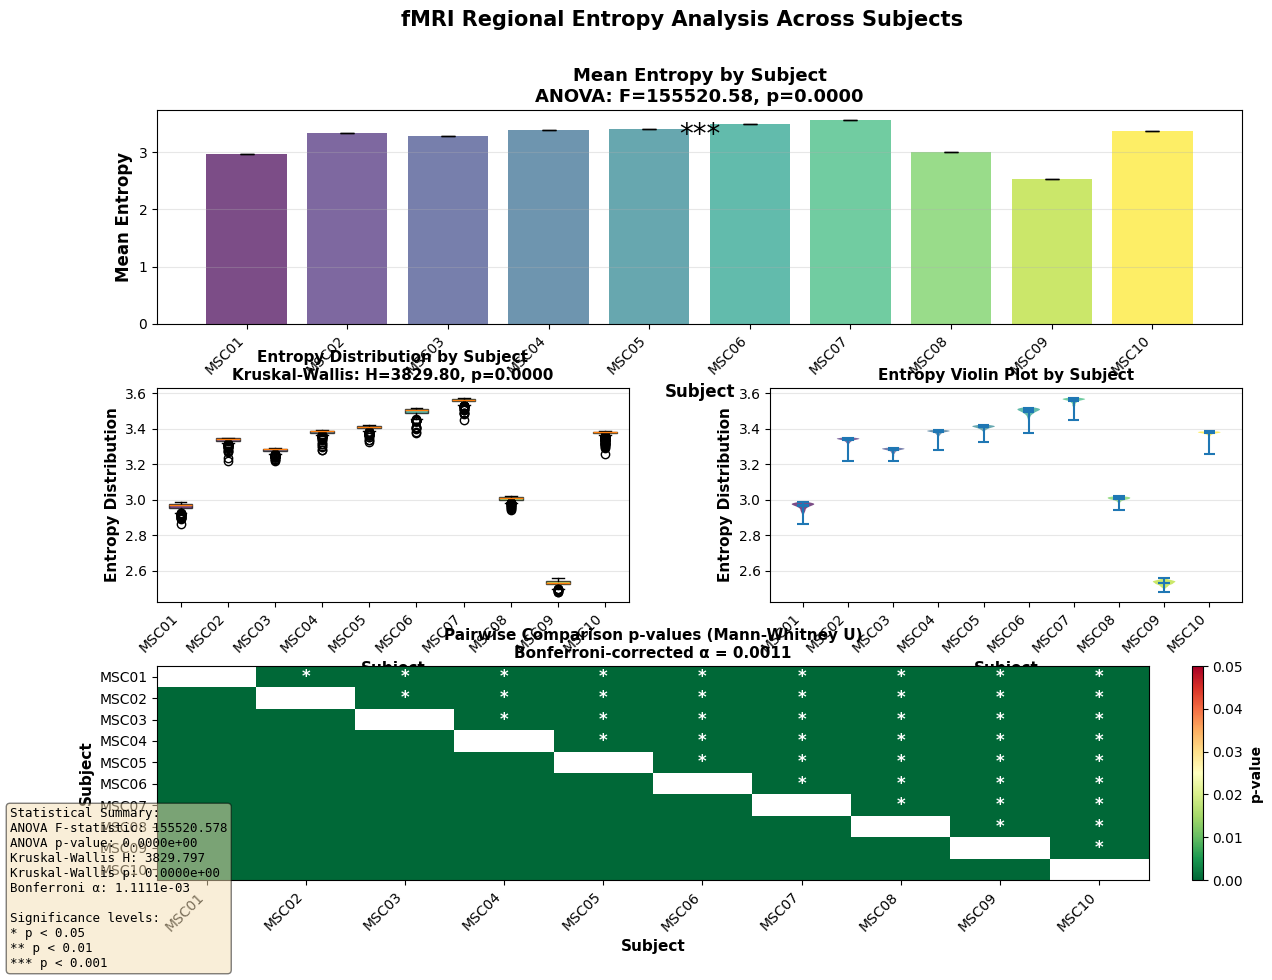

STATISTICAL ANALYSIS SUMMARY

1. One-Way ANOVA
   F-statistic: 155520.5776
   p-value: 0.0000e+00
   Significant: Yes

2. Kruskal-Wallis Test (non-parametric)
   H-statistic: 3829.7970
   p-value: 0.0000e+00
   Significant: Yes

3. Pairwise Comparisons (Mann-Whitney U)
   Total comparisons: 45
   Bonferroni-corrected α: 1.1111e-03
   Significant pairs: 45
      MSC01 vs MSC02: p = 9.9662e-130
      MSC01 vs MSC03: p = 9.9662e-130
      MSC01 vs MSC04: p = 9.9662e-130
      MSC01 vs MSC05: p = 9.9662e-130
      MSC01 vs MSC06: p = 9.9662e-130
      MSC01 vs MSC07: p = 9.9662e-130
      MSC01 vs MSC08: p = 1.8940e-120
      MSC01 vs MSC09: p = 9.9662e-130
      MSC01 vs MSC10: p = 9.9662e-130
      MSC02 vs MSC03: p = 2.1018e-123
      MSC02 vs MSC04: p = 2.9872e-119
      MSC02 vs MSC05: p = 1.0150e-126
      MSC02 vs MSC06: p = 9.9662e-130
      MSC02 vs MSC07: p = 9.9662e-130
      MSC02 vs MSC08: p = 9.9661e-130
      MSC02 vs MSC09: p = 9.9661e-130
      MSC02 vs MSC10: p = 2.0801e-

In [12]:
n_subjects = len(subjects)
subject_labels = subjects

# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
std_entropy = np.std(entropy_data, axis=1)
sem_entropy = stats.sem(entropy_data, axis=1)

# Perform statistical tests
# 1. One-way ANOVA to test if there are significant differences between subjects
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# 2. Kruskal-Wallis test (non-parametric alternative)
h_stat, p_value_kw = stats.kruskal(*[entropy_data[i, :] for i in range(n_subjects)])

# 3. Post-hoc pairwise comparisons (Wilcoxon with Bonferroni correction)
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

# Create figure with multiple subplots
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Bar plot with error bars
ax1 = fig.add_subplot(gs[0, :])
x_pos = np.arange(n_subjects)
bars = ax1.bar(x_pos, mean_entropy, yerr=sem_entropy, capsize=5, 
               alpha=0.7, color=plt.cm.viridis(np.linspace(0, 1, n_subjects)))
ax1.set_xlabel('Subject', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Entropy', fontsize=12, fontweight='bold')
ax1.set_title(f'Mean Entropy by Subject\nANOVA: F={f_stat:.2f}, p={p_value_anova:.4f}', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(subject_labels, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add significance stars if ANOVA is significant
if p_value_anova < 0.001:
    ax1.text(0.5, 0.95, '***', transform=ax1.transAxes, 
             fontsize=20, ha='center', va='top')
elif p_value_anova < 0.01:
    ax1.text(0.5, 0.95, '**', transform=ax1.transAxes, 
             fontsize=20, ha='center', va='top')
elif p_value_anova < 0.05:
    ax1.text(0.5, 0.95, '*', transform=ax1.transAxes, 
             fontsize=20, ha='center', va='top')

# 2. Box plot
ax2 = fig.add_subplot(gs[1, 0])
bp = ax2.boxplot([entropy_data[i, :] for i in range(n_subjects)],
                  labels=subject_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, n_subjects))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax2.set_ylabel('Entropy Distribution', fontsize=11, fontweight='bold')
ax2.set_title(f'Entropy Distribution by Subject\nKruskal-Wallis: H={h_stat:.2f}, p={p_value_kw:.4f}', 
              fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# 3. Violin plot
ax3 = fig.add_subplot(gs[1, 1])
parts = ax3.violinplot([entropy_data[i, :] for i in range(n_subjects)],
                        positions=range(n_subjects), showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], plt.cm.viridis(np.linspace(0, 1, n_subjects))):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax3.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax3.set_ylabel('Entropy Distribution', fontsize=11, fontweight='bold')
ax3.set_title('Entropy Violin Plot by Subject', fontsize=11, fontweight='bold')
ax3.set_xticks(range(n_subjects))
ax3.set_xticklabels(subject_labels, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Heatmap of pairwise comparisons
ax4 = fig.add_subplot(gs[2, :])
pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Mask diagonal and apply Bonferroni correction for visualization
pairwise_p_masked = np.ma.masked_where(np.eye(n_subjects, dtype=bool), pairwise_p)
im = ax4.imshow(pairwise_p_masked, cmap='RdYlGn_r', aspect='auto', 
                vmin=0, vmax=0.05, interpolation='nearest')
ax4.set_xticks(range(n_subjects))
ax4.set_yticks(range(n_subjects))
ax4.set_xticklabels(subject_labels, rotation=45, ha='right')
ax4.set_yticklabels(subject_labels)
ax4.set_title(f'Pairwise Comparison p-values (Mann-Whitney U)\nBonferroni-corrected α = {bonferroni_alpha:.4f}', 
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax4.set_ylabel('Subject', fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
cbar.set_label('p-value', fontsize=10, fontweight='bold')

# Add asterisks for significant comparisons
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            ax4.text(j, i, '*', ha='center', va='center', 
                    color='white', fontsize=12, fontweight='bold')

# Add overall statistics text box
stats_text = f"""Statistical Summary:
ANOVA F-statistic: {f_stat:.3f}
ANOVA p-value: {p_value_anova:.4e}
Kruskal-Wallis H: {h_stat:.3f}
Kruskal-Wallis p: {p_value_kw:.4e}
Bonferroni α: {bonferroni_alpha:.4e}

Significance levels:
* p < 0.05
** p < 0.01
*** p < 0.001"""

fig.text(0.02, 0.02, stats_text, fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         verticalalignment='bottom', family='monospace')

plt.suptitle('fMRI Regional Entropy Analysis Across Subjects', 
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('entropy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("="*60)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*60)
print(f"\n1. One-Way ANOVA")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   p-value: {p_value_anova:.4e}")
print(f"   Significant: {'Yes' if p_value_anova < 0.05 else 'No'}")

print(f"\n2. Kruskal-Wallis Test (non-parametric)")
print(f"   H-statistic: {h_stat:.4f}")
print(f"   p-value: {p_value_kw:.4e}")
print(f"   Significant: {'Yes' if p_value_kw < 0.05 else 'No'}")

print(f"\n3. Pairwise Comparisons (Mann-Whitney U)")
print(f"   Total comparisons: {n_comparisons}")
print(f"   Bonferroni-corrected α: {bonferroni_alpha:.4e}")

sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((subject_labels[i], subject_labels[j], pairwise_p[i, j]))

if sig_pairs:
    print(f"   Significant pairs: {len(sig_pairs)}")
    for s1, s2, p in sig_pairs:
        print(f"      {s1} vs {s2}: p = {p:.4e}")
else:
    print(f"   No significant pairwise differences after correction")

print("\n" + "="*60)

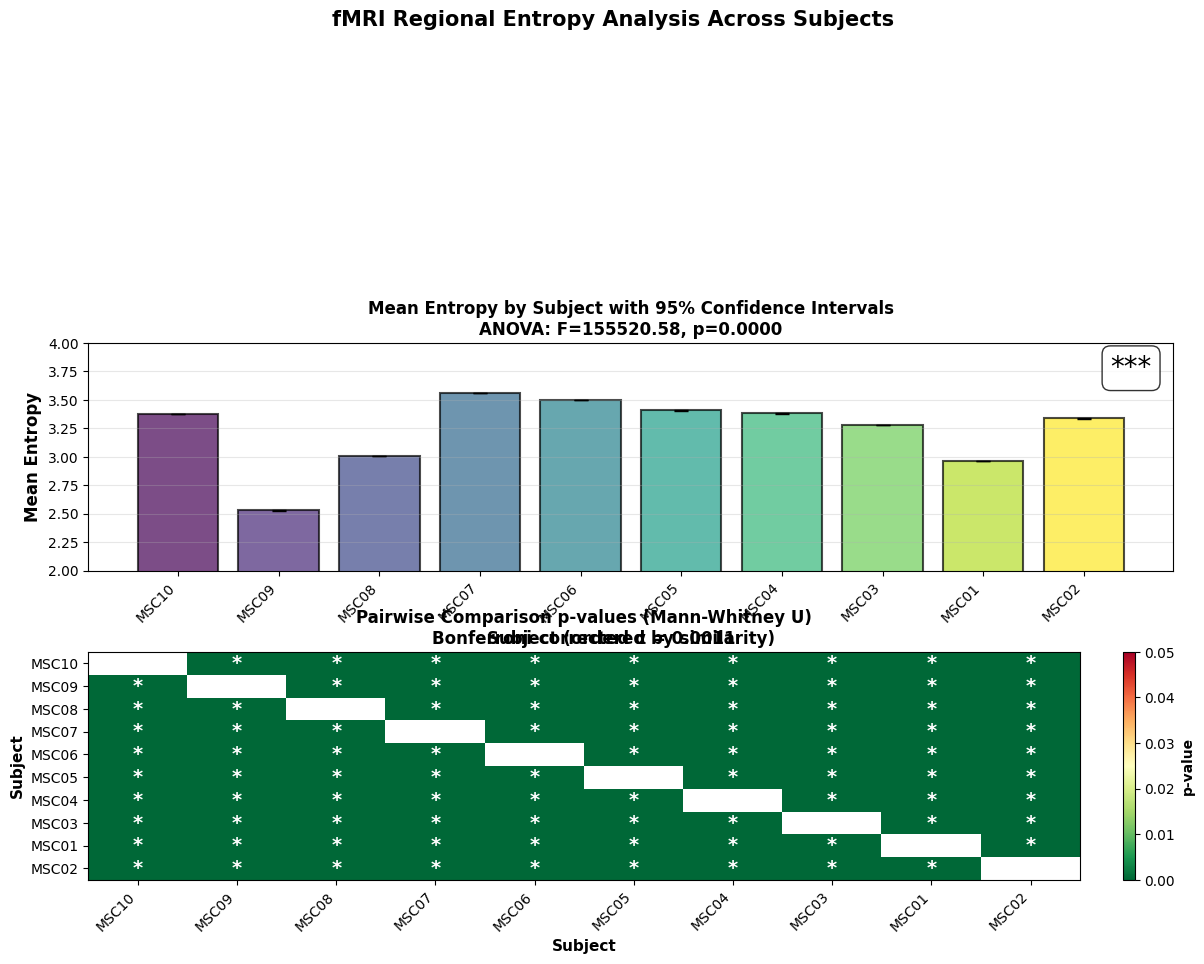

STATISTICAL ANALYSIS SUMMARY

1. One-Way ANOVA
   F-statistic: 155520.5776
   p-value: 0.0000e+00
   Significant: Yes

2. 95% Confidence Intervals
   Calculated using t-distribution with df=391

3. Pairwise Comparisons (Mann-Whitney U)
   Total comparisons: 45
   Bonferroni-corrected α: 1.1111e-03
   Significant pairs: 45
      MSC01 vs MSC02: p = 9.9662e-130
      MSC01 vs MSC03: p = 9.9662e-130
      MSC01 vs MSC04: p = 9.9662e-130
      MSC01 vs MSC05: p = 9.9662e-130
      MSC01 vs MSC06: p = 9.9662e-130
      MSC01 vs MSC07: p = 9.9662e-130
      MSC01 vs MSC08: p = 1.8940e-120
      MSC01 vs MSC09: p = 9.9662e-130
      MSC01 vs MSC10: p = 9.9662e-130
      MSC02 vs MSC03: p = 2.1018e-123
      MSC02 vs MSC04: p = 2.9872e-119
      MSC02 vs MSC05: p = 1.0150e-126
      MSC02 vs MSC06: p = 9.9662e-130
      MSC02 vs MSC07: p = 9.9662e-130
      MSC02 vs MSC08: p = 9.9661e-130
      MSC02 vs MSC09: p = 9.9661e-130
      MSC02 vs MSC10: p = 2.0801e-102
      MSC03 vs MSC04: p = 3.28

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

n_regions = len(entropy_data[0, :])

# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
std_entropy = np.std(entropy_data, axis=1)
sem_entropy = stats.sem(entropy_data, axis=1)

# Calculate 95% confidence intervals
confidence_level = 0.95
degrees_freedom = n_regions - 1
t_value = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
ci_entropy = t_value * sem_entropy

# Perform statistical tests
# One-way ANOVA to test if there are significant differences between subjects
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# Post-hoc pairwise comparisons (Wilcoxon with Bonferroni correction)
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

# Create pairwise distance matrix based on p-values
pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Create distance matrix for hierarchical clustering (convert p-values to distances)
# Use -log10(p-value) so that smaller p-values = larger distances = more different
distance_matrix = -np.log10(pairwise_p + 1e-10)  # Add small value to avoid log(0)
np.fill_diagonal(distance_matrix, 0)

# Perform hierarchical clustering
# Convert to condensed distance matrix for linkage
from scipy.spatial.distance import squareform
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, method='average')

# Create figure with adjusted layout
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 1, hspace=0.4, height_ratios=[1, 1.5, 1.5])


# 2. Bar plot with 95% confidence intervals
ax2 = fig.add_subplot(gs[1])
x_pos = np.arange(n_subjects)
ax2.set_ylim(2, 4)

# Get dendrogram leaf order to sort subjects by similarity
dend = dendrogram(linkage_matrix, no_plot=True)
leaf_order = dend['leaves']
sorted_labels = [subject_labels[i] for i in leaf_order]
sorted_means = mean_entropy[leaf_order]
sorted_ci = ci_entropy[leaf_order]

bars = ax2.bar(x_pos, sorted_means, yerr=sorted_ci, capsize=5, 
               alpha=0.7, color=plt.cm.viridis(np.linspace(0, 1, n_subjects)),
               edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Subject (ordered by similarity)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Entropy', fontsize=12, fontweight='bold')
ax2.set_title(f'Mean Entropy by Subject with 95% Confidence Intervals\nANOVA: F={f_stat:.2f}, p={p_value_anova:.4f}', 
              fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add significance notation
if p_value_anova < 0.001:
    sig_text = '***'
elif p_value_anova < 0.01:
    sig_text = '**'
elif p_value_anova < 0.05:
    sig_text = '*'
else:
    sig_text = 'ns'
ax2.text(0.98, 0.95, sig_text, transform=ax2.transAxes, 
         fontsize=20, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Heatmap of pairwise comparisons (reordered by dendrogram)
ax3 = fig.add_subplot(gs[2])

# Reorder matrix according to dendrogram
pairwise_p_reordered = pairwise_p[leaf_order, :][:, leaf_order]

# Mask diagonal
pairwise_p_masked = np.ma.masked_where(np.eye(n_subjects, dtype=bool), pairwise_p_reordered)
im = ax3.imshow(pairwise_p_masked, cmap='RdYlGn_r', aspect='auto', 
                vmin=0, vmax=0.05, interpolation='nearest')
ax3.set_xticks(range(n_subjects))
ax3.set_yticks(range(n_subjects))
ax3.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax3.set_yticklabels(sorted_labels)
ax3.set_title(f'Pairwise Comparison p-values (Mann-Whitney U)\nBonferroni-corrected α = {bonferroni_alpha:.4f}', 
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Subject', fontsize=11, fontweight='bold')
ax3.set_ylabel('Subject', fontsize=11, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('p-value', fontsize=10, fontweight='bold')

# Add asterisks for significant comparisons after Bonferroni correction
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p_reordered[i, j] < bonferroni_alpha:
            ax3.text(j, i, '*', ha='center', va='center', 
                    color='white', fontsize=14, fontweight='bold')
            ax3.text(i, j, '*', ha='center', va='center', 
                    color='white', fontsize=14, fontweight='bold')

plt.suptitle('fMRI Regional Entropy Analysis Across Subjects', 
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('entropy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print("="*60)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*60)
print(f"\n1. One-Way ANOVA")
print(f"   F-statistic: {f_stat:.4f}")
print(f"   p-value: {p_value_anova:.4e}")
print(f"   Significant: {'Yes' if p_value_anova < 0.05 else 'No'}")

print(f"\n2. 95% Confidence Intervals")
print(f"   Calculated using t-distribution with df={degrees_freedom}")

print(f"\n3. Pairwise Comparisons (Mann-Whitney U)")
print(f"   Total comparisons: {n_comparisons}")
print(f"   Bonferroni-corrected α: {bonferroni_alpha:.4e}")

sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((subject_labels[i], subject_labels[j], pairwise_p[i, j]))

if sig_pairs:
    print(f"   Significant pairs: {len(sig_pairs)}")
    for s1, s2, p in sig_pairs:
        print(f"      {s1} vs {s2}: p = {p:.4e}")
else:
    print(f"   No significant pairwise differences after correction")

print("\n" + "="*60)

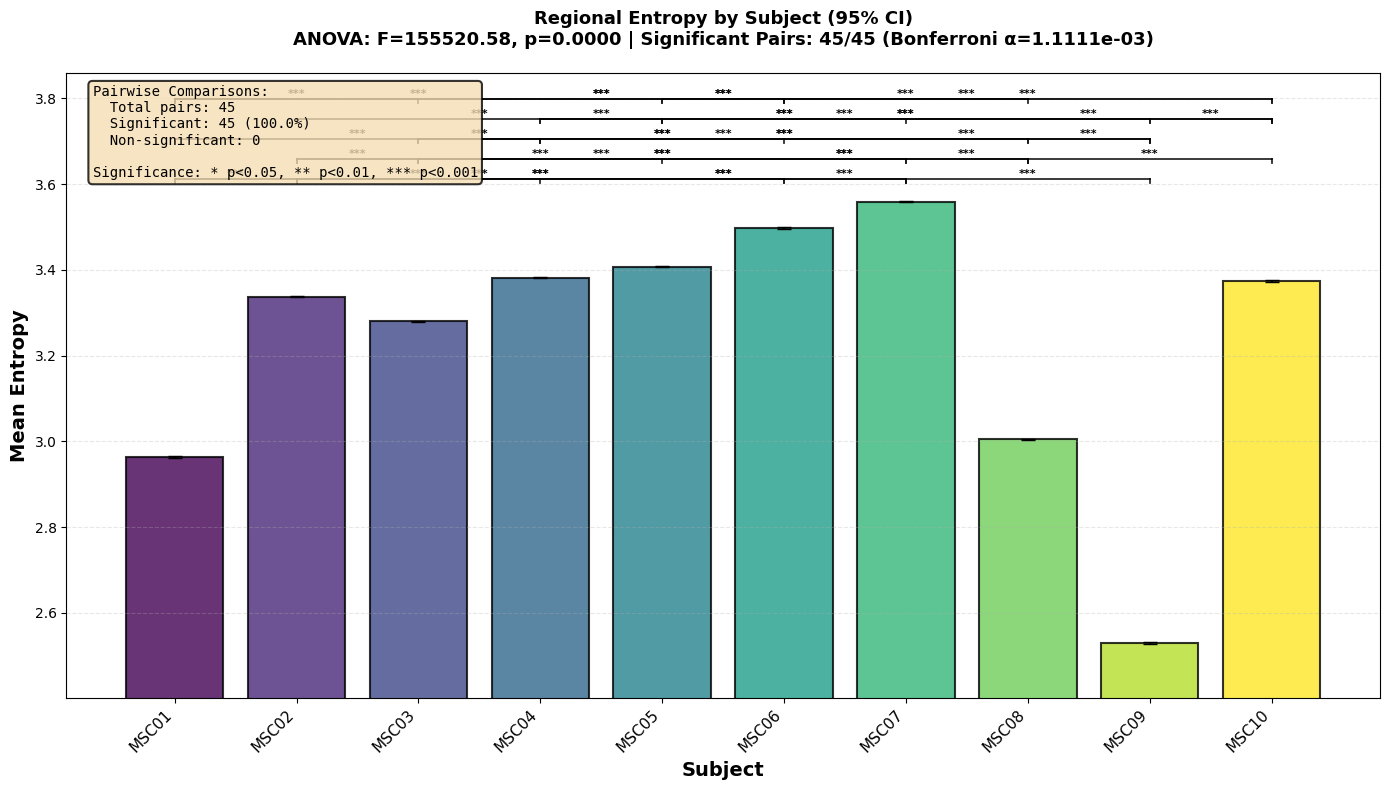

STATISTICAL SUMMARY
ANOVA: F=155520.5776, p=0.0000e+00

Pairwise Comparisons (Mann-Whitney U):
  Bonferroni-corrected α: 1.1111e-03
  Significant pairs: 45/45 (100.0%)

  *** ALL PAIRWISE COMPARISONS ARE SIGNIFICANT ***


In [14]:
# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
confidence_level = 0.95
degrees_freedom = n_regions - 1
sem_entropy = stats.sem(entropy_data, axis=1)
t_value = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
ci_entropy = t_value * sem_entropy

# Perform statistical tests
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# Post-hoc pairwise comparisons
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

# Calculate all pairwise comparisons
pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Count significant pairs
sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((i, j, pairwise_p[i, j]))

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Bar plot with 95% confidence intervals
x_pos = np.arange(n_subjects)
bars = ax.bar(x_pos, mean_entropy, yerr=ci_entropy, capsize=5, 
              alpha=0.8, color=plt.cm.viridis(np.linspace(0, 1, n_subjects)),
              edgecolor='black', linewidth=1.5)

ax.set_xlabel('Subject', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Entropy', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(subject_labels, rotation=45, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add title with statistics
title_text = f'Regional Entropy by Subject (95% CI)\n'
title_text += f'ANOVA: F={f_stat:.2f}, p={p_value_anova:.4f} | '
title_text += f'Significant Pairs: {len(sig_pairs)}/{n_comparisons} (Bonferroni α={bonferroni_alpha:.4e})'
ax.set_title(title_text, fontsize=13, fontweight='bold', pad=20)

# Draw significance brackets between all significant pairs
y_max = (mean_entropy + ci_entropy).max()
y_range = y_max - (mean_entropy - ci_entropy).min()
bracket_height = y_range * 0.03
starting_height = y_max + y_range * 0.05

# Sort pairs by distance to minimize overlap
sig_pairs_sorted = sorted(sig_pairs, key=lambda x: abs(x[0] - x[1]))

# Draw brackets in layers to reduce overlap
max_concurrent = 5  # Maximum number of brackets to show at same height
layer_heights = [starting_height + i * bracket_height * 1.5 for i in range(max_concurrent)]

for idx, (i, j, p) in enumerate(sig_pairs_sorted):
    layer = idx % max_concurrent
    y_height = layer_heights[layer]
    
    # Draw bracket
    x1, x2 = x_pos[i], x_pos[j]
    
    # Horizontal line
    ax.plot([x1, x2], [y_height, y_height], 'k-', linewidth=1.2, alpha=0.6)
    
    # Vertical ticks
    tick_height = bracket_height * 0.3
    ax.plot([x1, x1], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.6)
    ax.plot([x2, x2], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.6)
    
    # Add asterisk for significance level
    if p < 0.001:
        sig_marker = '***'
    elif p < 0.01:
        sig_marker = '**'
    elif p < 0.05:
        sig_marker = '*'
    else:
        sig_marker = ''
    
    # Only show asterisk on less crowded brackets
    # if layer < 2 or (j - i) <= 2:  # Show on close pairs or first two layers
    ax.text((x1 + x2) / 2, y_height + bracket_height * 0.01, sig_marker, 
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Adjust y-axis to accommodate brackets
if len(sig_pairs) > 0:
    max_layer = min(len(sig_pairs) - 1, max_concurrent - 1)
    ax.set_ylim(bottom=(mean_entropy - ci_entropy).min() * 0.95, 
                top=layer_heights[max_layer] + bracket_height * 2)

# Add text box with summary statistics
summary_text = f'Pairwise Comparisons:\n'
summary_text += f'  Total pairs: {n_comparisons}\n'
summary_text += f'  Significant: {len(sig_pairs)} ({100*len(sig_pairs)/n_comparisons:.1f}%)\n'
summary_text += f'  Non-significant: {n_comparisons - len(sig_pairs)}\n'
summary_text += f'\nSignificance: * p<0.05, ** p<0.01, *** p<0.001'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')


plt.tight_layout()
plt.savefig('entropy_bar_plot_with_significance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(f"ANOVA: F={f_stat:.4f}, p={p_value_anova:.4e}")
print(f"\nPairwise Comparisons (Mann-Whitney U):")
print(f"  Bonferroni-corrected α: {bonferroni_alpha:.4e}")
print(f"  Significant pairs: {len(sig_pairs)}/{n_comparisons} ({100*len(sig_pairs)/n_comparisons:.1f}%)")
if len(sig_pairs) == n_comparisons:
    print("\n  *** ALL PAIRWISE COMPARISONS ARE SIGNIFICANT ***")
print("="*60)

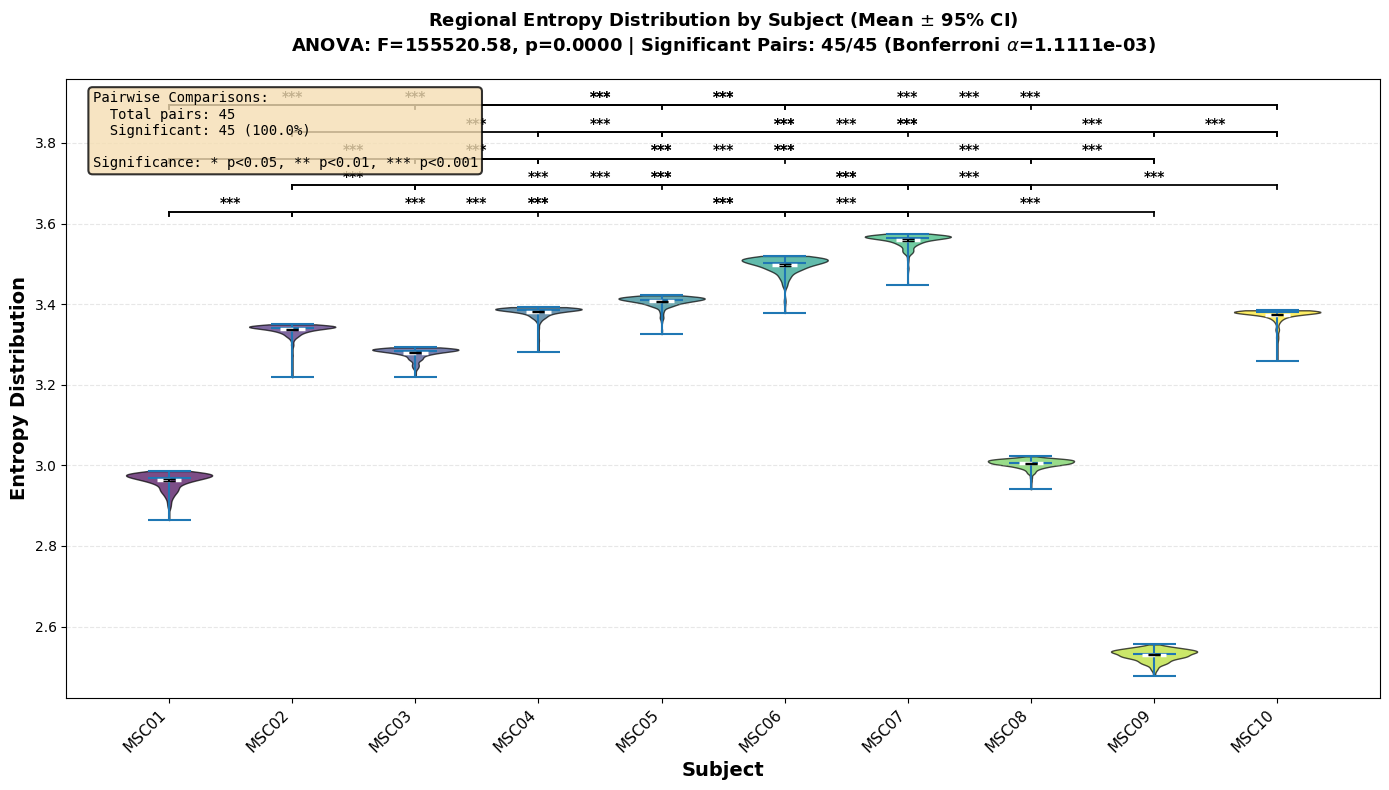

In [15]:

# --- STATISTICAL CALCULATIONS (From your original script) ---
# Calculate statistics
mean_entropy = np.mean(entropy_data, axis=1)
confidence_level = 0.95
n_regions = entropy_data.shape[1]
degrees_freedom = n_regions - 1
sem_entropy = stats.sem(entropy_data, axis=1)
t_value = stats.t.ppf((1 + confidence_level) / 2, degrees_freedom)
ci_entropy = t_value * sem_entropy

# Perform statistical tests (ANOVA)
f_stat, p_value_anova = stats.f_oneway(*[entropy_data[i, :] for i in range(n_subjects)])

# Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction)
n_comparisons = n_subjects * (n_subjects - 1) // 2
alpha = 0.05
bonferroni_alpha = alpha / n_comparisons

pairwise_p = np.ones((n_subjects, n_subjects))
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        stat, p = stats.mannwhitneyu(entropy_data[i, :], entropy_data[j, :])
        pairwise_p[i, j] = p
        pairwise_p[j, i] = p

# Count significant pairs
sig_pairs = []
for i in range(n_subjects):
    for j in range(i+1, n_subjects):
        if pairwise_p[i, j] < bonferroni_alpha:
            sig_pairs.append((i, j, pairwise_p[i, j]))


# --- VIOLIN PLOT CODE ---
fig, ax = plt.subplots(figsize=(14, 8))

# Data for violin plot (list of arrays)
data_to_plot = [entropy_data[i, :] for i in range(n_subjects)]
x_pos = np.arange(n_subjects)

# 1. Create the violin plots
violins = ax.violinplot(
    data_to_plot,
    positions=x_pos,
    vert=True,
    widths=0.7,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

# Color the violins
colors = plt.cm.viridis(np.linspace(0, 1, n_subjects))
for i, pc in enumerate(violins['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)

# 2. Highlight mean and 95% CI with error bars
for i in range(n_subjects):
    # Mean as a dashed white line
    ax.hlines(mean_entropy[i], x_pos[i] - 0.1, x_pos[i] + 0.1, 
              color='white', linestyle='--', linewidth=2.5, zorder=3)
    # CI as a black error bar/whisker (using fmt='none' for just the error bars)
    ax.errorbar(x_pos[i], mean_entropy[i], yerr=ci_entropy[i], fmt='none', 
                color='black', capsize=4, markersize=4, linewidth=1.5, zorder=4)

# --- AXIS LABELS AND TITLE ---
ax.set_xlabel('Subject', fontsize=14, fontweight='bold')
ax.set_ylabel('Entropy Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(subject_labels, rotation=45, ha='right', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

title_text = f'Regional Entropy Distribution by Subject (Mean $\\pm$ 95% CI)\n'
title_text += f'ANOVA: F={f_stat:.2f}, p={p_value_anova:.4f} | '
title_text += f'Significant Pairs: {len(sig_pairs)}/{n_comparisons} (Bonferroni $\\alpha$={bonferroni_alpha:.4e})'
ax.set_title(title_text, fontsize=13, fontweight='bold', pad=20)

# 3. Significance Brackets (adapted for the violin plot y-range)
y_max = entropy_data.max()
y_min = entropy_data.min()
y_range = y_max - y_min
bracket_height = y_range * 0.03
starting_height = y_max + y_range * 0.05

sig_pairs_sorted = sorted(sig_pairs, key=lambda x: abs(x[0] - x[1]))
max_concurrent = 5
layer_heights = [starting_height + i * bracket_height * 2 for i in range(max_concurrent)]

for idx, (i, j, p) in enumerate(sig_pairs_sorted):
    layer = idx % max_concurrent
    y_height = layer_heights[layer]
    x1, x2 = x_pos[i], x_pos[j]

    # Draw bracket
    ax.plot([x1, x2], [y_height, y_height], 'k-', linewidth=1.2, alpha=0.8)
    tick_height = bracket_height * 0.3
    ax.plot([x1, x1], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.8)
    ax.plot([x2, x2], [y_height - tick_height, y_height], 'k-', linewidth=1.2, alpha=0.8)

    # Add asterisk
    if p < 0.001:
        sig_marker = '***'
    elif p < 0.01:
        sig_marker = '**'
    elif p < 0.05:
        sig_marker = '*'
    else:
        sig_marker = ''

    ax.text((x1 + x2) / 2, y_height + bracket_height * 0.1, sig_marker,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust y-axis to accommodate brackets
if len(sig_pairs) > 0:
    max_layer = min(len(sig_pairs) - 1, max_concurrent - 1)
    ax.set_ylim(bottom=y_min - y_range * 0.05,
                top=layer_heights[max_layer] + bracket_height * 2)

# Add text box with summary statistics
summary_text = f'Pairwise Comparisons:\n'
summary_text += f'  Total pairs: {n_comparisons}\n'
summary_text += f'  Significant: {len(sig_pairs)} ({100*len(sig_pairs)/n_comparisons:.1f}%)\n'
summary_text += f'\nSignificance: * p<0.05, ** p<0.01, *** p<0.001'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=1.5)
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

## **Matrix Comparison**

In [55]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

atlas = 'glasser360_SUIT_Thalamus'
atlas_subdir = 'glasser360_SUIT_Thalamus'

other_suffix = ''
cov = {}
cov[num_bins] = load_data(subjects=subjects, measure="covariance", task=task, atlas=atlas, atlas_subdir=atlas_subdir, skl=False, num_bins=num_bins, other_suffix=other_suffix)

In [56]:
for subject in subjects:
    cov[num_bins][subject] = cov[num_bins][subject][np.ix_(keep_indices, keep_indices)]

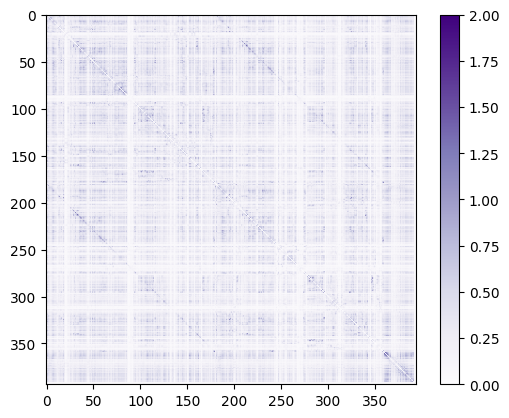

In [57]:
plt.imshow(mi_gst[100]['MSC09'], vmax=2, cmap='Purples')
plt.colorbar()

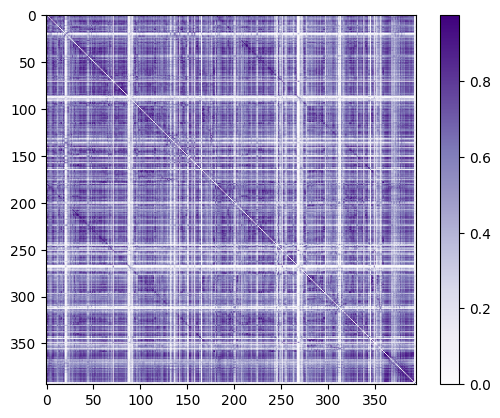

In [58]:
plt.imshow(cov[100]['MSC09'], vmin=0, vmax=max(cov[100]['MSC09'].flatten()), cmap='Purples')
plt.colorbar()

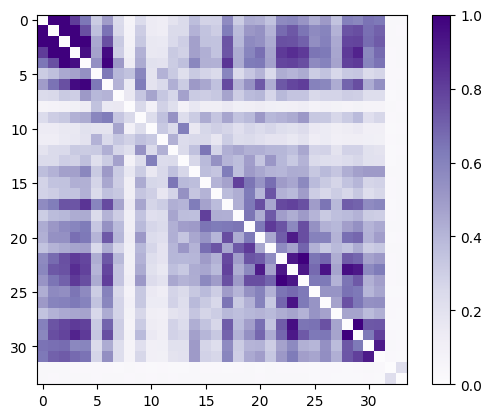

In [61]:
plt.imshow(mi_gst[100]['MSC09'][360:, 360:], vmin=0, vmax=1, cmap='Purples')
plt.colorbar()

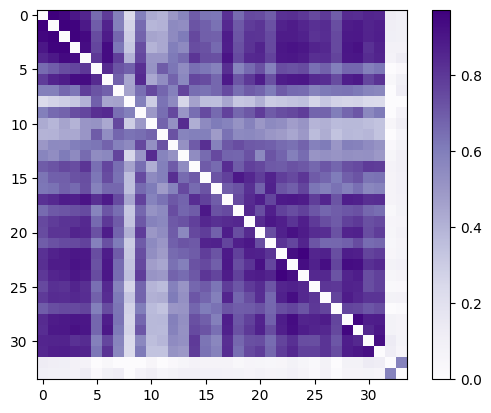

In [60]:
plt.imshow(cov[100]['MSC09'][360:, 360:], vmin=0, cmap='Purples')
plt.colorbar()

## **Chow-Liu trees**

In [66]:
subjects = [
            'MSC01', 
            # 'MSC02',
            # 'MSC03',
            'MSC04',
            # 'MSC05', 
            # 'MSC06',
            'MSC07', 
            # 'MSC08',
            'MSC09',
            # 'MSC10'
            ]

atlas = 'glasser360_SUIT_Thalamus'
atlas_subdir = 'glasser360_SUIT_Thalamus'

def load_data(subjects=subjects, measure="mutual_information", task="rest", atlas="Schaefer", atlas_subdir="schaefer_100", skl=False, num_bins=100):
    """
    Save the covariance matrix to a CSV file.
    """
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        if skl:
            file_name = f'{task}_skl_{num_bins}bins'
        else:
            file_name = f'{task}_{num_bins}bins'

        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data

def plot_connectome(cov_matrix, coords, title='connectome', edge_threshold="0%", edge_vmin=0, edge_vmax=1):
    """
    Plot the connectome using the mean correlation matrix and coordinates.
    """
    # Plotting the connectome
    plotting.plot_connectome(
        cov_matrix,
        coords,
        title=title,
        edge_vmin = edge_vmin,
        edge_vmax = edge_vmax,
        edge_cmap='cold_hot',
        edge_threshold=edge_threshold,  # Only plot edges above the 90th percentile
        colorbar=True,
        node_size=10,
    )
    plt.show()

def mi_to_graph(mi, selected_nodes=None):
    
    # Create a graph
    G = nx.Graph()
    num_variables = mi.shape[0]
    
    if selected_nodes is not None:
        for i in selected_nodes:
            G.add_node(i)
        
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(selected_nodes[i], selected_nodes[j], weight=mi[i, j])

    else:
        # Add nodes (variables)
        for i in range(num_variables):
            G.add_node(i)

    # Add edges with mutual information as weights
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(i, j, weight=mi[i, j])
    
    return G

def chow_liu_tree(mi):
    
    # Create a graph
    G = mi_to_graph(mi)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_chow_liu_trees(mi, joint_probs, subjects=subjects):

    cl_trees = {}
    cl_matrices = {}
    cl_joint_probs = {}
    for subject in subjects:
        _, cl_trees[subject] = chow_liu_tree(mi[subject])
        cl_matrices[subject] = torch.from_numpy(nx.to_numpy_array(cl_trees[subject], weight='weight'))
        cl_joint_probs[subject] = {}
        for edge in cl_trees[subject].edges():
            i, j = edge
            cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return cl_trees, cl_matrices, cl_joint_probs

def draw_chow_liu_tree(G, root=0):
    """
    Visualize the Chow-Liu tree using a spring layout (no pygraphviz).
    """
    tree = nx.bfs_tree(G, source=root)
    pos = nx.spring_layout(tree, seed=42)

    plt.figure(figsize=(8, 6))
    nx.draw(tree, pos, with_labels=True, arrows=False, node_color="lightblue", 
            edge_color="black", node_size=1500, font_size=12)
    
    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels)

    plt.title("Chow-Liu Tree (Spring Layout)")
    plt.axis("off")
    plt.show()


def hierarchy_pos(G, root=None, width=1., vert_gap=0.5, vert_loc=0, xcenter=0.5):
    """
    Hierarchical layout for directed trees. Assigns space to subtrees to avoid squishing.
    """
    def _count_descendants(G, node):
        children = list(G.successors(node))
        if not children:
            return 1
        return sum(_count_descendants(G, child) for child in children)

    def _hierarchy_pos(G, node, left, right, vert_loc, pos):
        center = (left + right) / 2
        pos[node] = (center, vert_loc)
        children = list(G.successors(node))
        if children:
            total = sum(_count_descendants(G, child) for child in children)
            dx = (right - left) / total
            next_left = left
            for child in children:
                size = _count_descendants(G, child)
                next_right = next_left + dx * size
                pos = _hierarchy_pos(G, child, next_left, next_right, vert_loc - vert_gap, pos)
                next_left = next_right
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, {})

def get_node_regions(tree, network_labels=None, region_labels=None, atlas_name='schaefer'):

    if atlas_name == 'schaefer':
        networks = []
        for node in tree.nodes:
            network = str(network_labels[node]).split('_')[2]
            networks.append(network)
        return networks
    
    elif atlas_name == 'glasser_suit':
        networks = []
        network_labels = list(region_labels) + ['Cerebellum']*32
        for node in tree.nodes:
            network = network_labels[node]
            networks.append(network)
        return networks
    
    elif atlas_name == 'glasser360_SUIT_Thalamus':
        networks = []
        network_labels = list(region_labels) + ['Cerebellum']*32 + ['Thalamus']*2
        for node in tree.nodes:
            network = network_labels[node]
            networks.append(network)
        return networks
    
def draw_hierarchical_tree(G, root=0, atlas_name='glasser_suit', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title = "Hierarchical Chow-Liu Tree", draw_tree=True, selected_networks=None):
    """
    Draw Chow-Liu tree in a hierarchical top-down format.
    """
    # Ensure it's a directed tree rooted at `root`
    tree = nx.bfs_tree(G, source=root)

    if not draw_tree:
        tree = G

    pos = hierarchy_pos(tree, root)
    if atlas_name == 'schaefer':
        networks = get_node_regions(tree, atlas_name='schaefer', network_labels=schaefer.labels)
    
    elif atlas_name == 'glasser_suit':
        networks = get_node_regions(tree, atlas_name='glasser_suit', region_labels=glasser_region_list['cortex'])
    
    elif atlas_name == 'glasser360_SUIT_Thalamus':
        networks = get_node_regions(tree, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])

    if atlas_name == 'schaefer':
        # Create a color map based on the networks

        network_names = ['Cont', 'Default', 'DorsAttn', 'Limbic', 'SalVentAttn', 'SomMot', 'Vis']
        colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']
        
        if num_schaefer_networks == 17:
            network_names = ['ContA',
                            'ContB',
                            'ContC',
                            'DefaultA',
                            'DefaultB',
                            'DefaultC',
                            'DorsAttnA',
                            'DorsAttnB',
                            'LimbicA',
                            'LimbicB',
                            'SalVentAttnA',
                            'SalVentAttnB',
                            'SomMotA',
                            'SomMotB',
                            'TempPar',
                            'VisCent',
                            'VisPeri']
            
            colors = colors = [
                                "#e6194b",  # red
                                "#3cb44b",  # green
                                "#ffe119",  # yellow
                                "#4363d8",  # blue
                                "#f58231",  # orange
                                "#911eb4",  # purple
                                "#46f0f0",  # cyan
                                "#f032e6",  # magenta
                                "#bcf60c",  # lime
                                "#fabebe",  # pink
                                "#008080",  # teal
                                "#e6beff",  # lavender
                                "#9a6324",  # brown
                                "#fffac8",  # beige
                                "#800000",  # maroon
                                "#aaffc3",  # mint
                                "#808000",  # olive      
                            ]
    
    if atlas_name == 'glasser_suit':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum']
        colors =          [
                            "#e6194b",  # red
                            "#3cb44b",  # green
                            "#ffe119",  # yellow
                            "#4363d8",  # blue
                            "#f58231",  # orange
                            "#911eb4",  # purple
                            "#46f0f0",  # cyan
                            "#f032e6",  # magenta
                            "#bcf60c",  # lime
                            "#fabebe",  # pink
                            "#008080",  # teal
                            "#e6beff",  # lavender
                            "#9a6324",  # brown
                            "#fffac8",  # beige
                            "#800000",  # maroon
                            "#aaffc3",  # mint
                            "#808000",  # olive
                            "#000075",  # navy
                            "#ffd8b1",  # peach
                            "#469990",  # turquoise
                            "#000000",  # black
                            "#ffffff",  # white
                            "#d2691e",  # chocolate
                            "#ff7f50",  # coral
                        ]
    if atlas_name == 'glasser360_SUIT_Thalamus':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']

        colors =          [
                            "#e6194b",  # red
                            "#3cb44b",  # green
                            "#ffe119",  # yellow
                            "#4363d8",  # blue
                            "#f58231",  # orange
                            "#911eb4",  # purple
                            "#46f0f0",  # cyan
                            "#f032e6",  # magenta
                            "#bcf60c",  # lime
                            "#fabebe",  # pink
                            "#008080",  # teal
                            "#e6beff",  # lavender
                            "#9a6324",  # brown
                            "#fffac8",  # beige
                            "#800000",  # maroon
                            "#aaffc3",  # mint
                            "#808000",  # olive
                            "#000075",  # navy
                            "#ffd8b1",  # peach
                            "#469990",  # turquoise
                            "#000000",  # black
                            "#ffffff",  # white
                            "#d2691e",  # chocolate
                            "#ff7f50",  # coral
                            "#40e0d0",  # turquoise bright
                            "#ff1493",  # deep pink
                            "#7fff00",  # chartreuse
                            "#1e90ff",  # dodger blue
                            "#ff4500",  # orange red
                            "#daa520",  # goldenrod
                        ]
        
        network_purples = [
            "#E1BEE7",  # Light (for background/less important)
            "#E0E0E0",  # Light Grey
            "#9FA8DA",  # Soft Violet
            "#7B1FA2",  # Dark
            "#4A148C",  # Very dark (for emphasis)
        ]
                
        if selected_networks is not None:
            network_names = selected_networks

            # edit later
            colors = network_purples[:len(selected_networks)]

    color_map = []
    print(networks)
    for node, network in zip(tree.nodes, networks):
        if network in network_names:
            color = colors[network_names.index(network)]
            color_map.append(color)
        else:
            color_map.append('white')
    # print(color_map)
    
    # color_map = np.array(color_map)
    # color_map = color_map / max(color_map)
    
    plt.figure(figsize=(10, 6))
    nx.draw(tree, pos, with_labels=True, node_color=color_map, node_size=140,
            arrows=False, font_size=6, edge_color='gray')


    # edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
    # nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size = 0)

    patches = [mpatches.Patch(color=color, label=network_name) for color, network_name in zip(colors, network_names)]
    plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

    return tree, pos, network_names, colors

In [63]:
def select_networks_schaefer(schaefer, networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    selected_nodes = []
    for i, label in enumerate(schaefer.labels):
        network = str(label).split('_')[2]
        if network in networks:
            selected_nodes.append(i)
    return selected_nodes

def select_networks_glasser(labels=list(glasser_region_list['cortex'])+['Cerebellum']*32, networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum']):
    
    selected_nodes = []
    node_names = []
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return selected_nodes

def select_networks_glasser360_SUIT_Thalamus(labels=list(glasser_region_list['cortex']) + ['Cerebellum']*32 + ['Thalamus']*2, networks=['Premotor', 'Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']):
    
    selected_nodes = []
    node_names = []
    print(labels)
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return node_names, selected_nodes

def selective_chow_liu_tree(mi, selected_nodes):
    
    # Create a graph
    selected_mi = mi[np.ix_(selected_nodes, selected_nodes)]
    
    G = mi_to_graph(selected_mi, selected_nodes=selected_nodes)

    # Find the maximum spanning tree
    # The weight parameter specifies the attribute used for edge weights
    chow_liu_tree = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    
    return G, chow_liu_tree

def get_selective_chow_liu_trees(mi, joint_probs, subjects=subjects, atlas_name='glasser_suit', schaefer=None, selected_networks=['DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB', 'VisCent', 'VisPeri']):
    
    if atlas_name == 'schaefer':
        node_names, selected_nodes = select_networks_schaefer(schaefer, networks=selected_networks)
    
    if atlas_name == 'glasser_suit':
        node_names, selected_nodes = select_networks_glasser(networks=selected_networks)
    
    if atlas_name == 'glasser360_SUIT_Thalamus_Brainstem':
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks)

    print(node_names)
    print(selected_nodes)
    selective_cl_trees = {}
    selective_cl_joint_probs = {}
    
    for subject in subjects:
        _, selective_cl_trees[subject] = selective_chow_liu_tree(mi[subject], selected_nodes=selected_nodes)
        selective_cl_joint_probs[subject] = {}
        for edge in selective_cl_trees[subject].edges():
            i, j = edge
            selective_cl_joint_probs[subject][edge] = joint_probs[subject][i, j, :, :]

    return selective_cl_trees, selective_cl_joint_probs, selected_nodes

In [64]:
# def sparse_covariance_top_edges(cov_matrix, atlas_name = 'glasser360_SUIT_Thalamus_Brainstem', selected_networks=None, selected_nodes=None):
#     """
#     Get the top N edges with the highest covariance values.
#     """

#     top_n=cov_matrix.shape[0]  # Number of nodes
#     # Flatten the covariance matrix and get the indices of the top N values
#     flat_indices = np.argsort(cov_matrix.flatten())[::-1][:top_n]
    
#     # Convert flat indices to 2D indices
#     row_indices, col_indices = np.unravel_index(flat_indices, cov_matrix.shape)
    
#     top_edges = np.zeros(cov_matrix.shape)
#     for i in range(top_n):
#         top_edges[row_indices[i], col_indices[i]] = cov_matrix[row_indices[i], col_indices[i]]
    

#     if selected_networks:
#         node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks) # add options later
    
#     if selected_nodes:

#         top_edges = top_edges[np.ix_(selected_nodes, selected_nodes)]
    
#     # Create a graph
#     G = nx.Graph()
#     num_variables = len(selected_nodes)
    
#     if selected_nodes:
#         for i in selected_nodes:
#             G.add_node(i)
        
#         for i in range(num_variables):
#             for j in range(i + 1, num_variables):
#                 if top_edges[selected_nodes[i], selected_nodes[j]] > 0:
#                     G.add_edge(selected_nodes[i], selected_nodes[j], weight=top_edges[i, j])

#     else:
#         # Add nodes (variables)
#         for i in range(num_variables):
#             G.add_node(i)

#     # Add edges with mutual information as weights
#         for i in range(num_variables):
#             for j in range(i + 1, num_variables):
#                 G.add_edge(i, j, weight=top_edges[i, j])
    
#     return G, selected_nodes

def sparse_covariance_top_edges(cov_matrix, atlas_name='glasser360_SUIT_Thalamus_Brainstem', selected_networks=None, selected_nodes=None, top_n=None):
    """
    Get the top N edges with the highest covariance values.
    """
    
    # First, subset the covariance matrix if needed
    if selected_networks:
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks)
    
    if selected_nodes is not None:
        cov_subset = cov_matrix[np.ix_(selected_nodes, selected_nodes)]
    else:
        cov_subset = cov_matrix
        selected_nodes = list(range(cov_matrix.shape[0]))
    
    # Determine top_n if not specified
    if top_n is None:
        top_n = cov_subset.shape[0]  # Default to number of nodes
    
    # Get upper triangle indices (to avoid duplicates and diagonal)
    upper_tri_indices = np.triu_indices_from(cov_subset, k=1)
    upper_tri_values = cov_subset[upper_tri_indices]
    
    # Get the indices of the top N values
    top_indices = np.argsort(upper_tri_values)[::-1][:top_n]
    
    # Create graph
    G = nx.Graph()
    
    # Add all nodes
    for node in selected_nodes:
        G.add_node(node)
    
    # Add only the top N edges
    for idx in top_indices:
        i = upper_tri_indices[0][idx]
        j = upper_tri_indices[1][idx]
        weight = cov_subset[i, j]
        if weight > 0:  # Optional: only add positive weights
            G.add_edge(selected_nodes[i], selected_nodes[j], weight=weight)
    
    return G, selected_nodes

In [67]:
def sparse_covariance_spanning_tree(cov_matrix, atlas_name='glasser360_SUIT_Thalamus_Brainstem', selected_networks=None, selected_nodes=None, additional_edges=0):
    """
    Get the minimum top edges needed to connect all nodes (maximum spanning tree).
    Uses Union-Find for efficient connectivity checking.
    """
    
    # First, subset the covariance matrix if needed
    if selected_networks:
        node_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(networks=selected_networks)
    
    if selected_nodes is not None:
        cov_subset = cov_matrix[np.ix_(selected_nodes, selected_nodes)]
    else:
        cov_subset = cov_matrix
        selected_nodes = list(range(cov_matrix.shape[0]))
    
    num_nodes = len(selected_nodes)
    
    # Get upper triangle indices (to avoid duplicates and diagonal)
    upper_tri_indices = np.triu_indices_from(cov_subset, k=1)
    upper_tri_values = cov_subset[upper_tri_indices]
    
    # Sort edges by weight (descending) - highest covariance first
    sorted_indices = np.argsort(upper_tri_values)[::-1]
    
    # Union-Find data structure for efficient cycle detection
    parent = {node: node for node in selected_nodes}
    rank = {node: 0 for node in selected_nodes}
    
    def find(node):
        if parent[node] != node:
            parent[node] = find(parent[node])  # Path compression
        return parent[node]
    
    def union(node1, node2):
        root1 = find(node1)
        root2 = find(node2)
        
        if root1 == root2:
            return False  # Already in same set (would create cycle)
        
        # Union by rank
        if rank[root1] < rank[root2]:
            parent[root1] = root2
        elif rank[root1] > rank[root2]:
            parent[root2] = root1
        else:
            parent[root2] = root1
            rank[root1] += 1
        
        return True  # Successfully merged two components
    
    # Create graph
    G = nx.Graph()
    
    # Add all nodes
    for node in selected_nodes:
        G.add_node(node)
    
    # Build maximum spanning tree using Kruskal's algorithm
    edges_added = 0
    min_edges_needed = num_nodes - 1
    edge_list = []
    
    for idx in sorted_indices:
        i = upper_tri_indices[0][idx]
        j = upper_tri_indices[1][idx]
        weight = cov_subset[i, j]
        
        node_i = selected_nodes[i]
        node_j = selected_nodes[j]
        
        # Try to add edge (only adds if it doesn't create a cycle)
        if union(node_i, node_j):
            G.add_edge(node_i, node_j, weight=weight)
            edge_list.append((idx, node_i, node_j, weight))
            edges_added += 1
            
            # Stop when we have a spanning tree
            if edges_added >= min_edges_needed:
                break
    
    print(f"Added {edges_added} edges to connect {num_nodes} nodes")
    
    # Add additional edges if requested
    if additional_edges > 0:
        remaining_idx = [idx for idx in sorted_indices if idx not in [e[0] for e in edge_list]]
        added_extra = 0
        
        for idx in remaining_idx:
            if added_extra >= additional_edges:
                break
            
            i = upper_tri_indices[0][idx]
            j = upper_tri_indices[1][idx]
            node_i = selected_nodes[i]
            node_j = selected_nodes[j]
            
            if not G.has_edge(node_i, node_j):
                G.add_edge(node_i, node_j, weight=cov_subset[i, j])
                added_extra += 1
        
        print(f"Added {added_extra} additional edges")
    
    # Verify connectivity
    if not nx.is_connected(G):
        print("WARNING: Graph is not connected! Some nodes may be isolated.")
    
    return G, selected_nodes

In [26]:
# def draw_covariance_graph(G, root=0, atlas_name='glasser360_SUIT_Thalamus', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title = "Hierarchical Chow-Liu Tree",  selected_networks=None):
        
#     if atlas_name == 'glasser360_SUIT_Thalamus':
#         network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']
#         networks = get_node_regions(G, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])


#         colors =          [
#                             "#e6194b",  # red
#                             "#3cb44b",  # green
#                             "#ffe119",  # yellow
#                             "#4363d8",  # blue
#                             "#f58231",  # orange
#                             "#911eb4",  # purple
#                             "#46f0f0",  # cyan
#                             "#f032e6",  # magenta
#                             "#bcf60c",  # lime
#                             "#fabebe",  # pink
#                             "#008080",  # teal
#                             "#e6beff",  # lavender
#                             "#9a6324",  # brown
#                             "#fffac8",  # beige
#                             "#800000",  # maroon
#                             "#aaffc3",  # mint
#                             "#808000",  # olive
#                             "#000075",  # navy
#                             "#ffd8b1",  # peach
#                             "#469990",  # turquoise
#                             "#000000",  # black
#                             "#ffffff",  # white
#                             "#d2691e",  # chocolate
#                             "#ff7f50",  # coral
#                             "#40e0d0",  # turquoise bright
#                             "#ff1493",  # deep pink
#                             "#7fff00",  # chartreuse
#                             "#1e90ff",  # dodger blue
#                             "#ff4500",  # orange red
#                             "#daa520",  # goldenrod
#                         ]
        
#         if selected_networks is not None:
#             network_names = selected_networks

#             # edit later
#             colors = [
#                     "#fabebe",  # pink     
#                     "#aaffc3",  # mint
#                     "#e6beff",  # lavender
#                         ]
        
#             color_map = []
            
#         print(networks)
#         for node, network in zip(G.nodes, networks):
#             if network in network_names:
#                 color = colors[network_names.index(network)]
#                 color_map.append(color)
#             else:
#                 color_map.append('white')
#         # print(color_map)
        
#         # color_map = np.array(color_map)
#         # color_map = color_map / max(color_map)
        
#         plt.figure(figsize=(10, 6))
#         nx.draw(G, with_labels=True, node_color=color_map, node_size=140,
#                 arrows=False, font_size=6, edge_color='gray')


#         # edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in tree.edges()}
#         # nx.draw_networkx_edge_labels(tree, pos, edge_labels=edge_labels, font_size = 0)

#         patches = [mpatches.Patch(color=color, label=network_name) for color, network_name in zip(colors, network_names)]
#         plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

#         plt.title(title, fontsize=14)
#         plt.axis('off')
#         plt.show()

#         return G, network_names, colors


In [27]:
# def draw_covariance_graph(G, root=0, atlas_name='glasser360_SUIT_Thalamus', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title="Sparsified Covariance Graph", selected_networks=None, layout='kamada'):
    
#     if atlas_name == 'glasser360_SUIT_Thalamus':
#         network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']
#         networks = get_node_regions(G, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])

#         colors = [
#             "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
#             "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080", "#e6beff",
#             "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#000075",
#             "#ffd8b1", "#469990", "#000000", "#ffffff", "#d2691e", "#ff7f50",
#             "#40e0d0", "#ff1493", "#7fff00", "#1e90ff", "#ff4500", "#daa520",
#         ]
        
#         if selected_networks is not None:
#             network_names = selected_networks
#             colors = ["#fabebe", "#aaffc3", "#e6beff"]
        
#         color_map = []
#         print(networks)
#         for node, network in zip(G.nodes, networks):
#             if network in network_names:
#                 color = colors[network_names.index(network)]
#                 color_map.append(color)
#             else:
#                 color_map.append('white')
        
#         # Choose layout algorithm
#         if layout == 'spring':
#             pos = nx.spring_layout(G, k=2, iterations=50, seed=42)  # k controls spacing
#         elif layout == 'kamada':
#             pos = nx.kamada_kawai_layout(G)
#         elif layout == 'spectral':
#             pos = nx.spectral_layout(G)
#         elif layout == 'circular':
#             pos = nx.circular_layout(G)
#         else:
#             pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
#         plt.figure(figsize=(14, 10))  # Larger figure
        
#         # Draw with the computed positions
#         nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=140)
#         nx.draw_networkx_labels(G, pos, font_size=6)
        
#         # Draw edges with transparency to see overlap
#         nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, width=0.5)
        
#         patches = [mpatches.Patch(color=color, label=network_name) 
#                    for color, network_name in zip(colors, network_names)]
#         plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
        
#         plt.title(f"{title}\n({G.number_of_edges()} edges, {G.number_of_nodes()} nodes)", 
#                   fontsize=14)
#         plt.axis('off')
#         plt.tight_layout()
#         plt.show()
        
#         print(f"Graph has {G.number_of_edges()} edges out of {G.number_of_nodes()*(G.number_of_nodes()-1)/2:.0f} possible edges")
        
#         return G, network_names, colors

In [68]:
def draw_covariance_graph(G, root=0, atlas_name='glasser360_SUIT_Thalamus', num_schaefer_networks=17, glasser_region_list=glasser_region_list, title="Sparsified Covariance Graph", selected_networks=None, layout='tree'):
    
    if atlas_name == 'glasser360_SUIT_Thalamus':
        network_names = np.unique(glasser_region_list['cortex']).tolist() + ['Cerebellum'] + ['Thalamus']
        networks = get_node_regions(G, atlas_name='glasser360_SUIT_Thalamus', region_labels=glasser_region_list['cortex'])

        colors = [
            "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4",
            "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", "#008080", "#e6beff",
            "#9a6324", "#fffac8", "#800000", "#aaffc3", "#808000", "#000075",
            "#ffd8b1", "#469990", "#000000", "#ffffff", "#d2691e", "#ff7f50",
            "#40e0d0", "#ff1493", "#7fff00", "#1e90ff", "#ff4500", "#daa520",
        ]
        network_purples = [
            "#E1BEE7",  # Light (for background/less important)
            "#E0E0E0",  # Light Grey
            "#9FA8DA",  # Soft Violet
            "#7B1FA2",  # Dark
            "#4A148C",  # Very dark (for emphasis)
        ]
                
        
        if selected_networks is not None:
            network_names = selected_networks
            colors = network_purples[:len(selected_networks)]
        
        color_map = []
        print(networks)
        for node, network in zip(G.nodes, networks):
            if network in network_names:
                color = colors[network_names.index(network)]
                color_map.append(color)
            else:
                color_map.append('white')
        
        # Get connected components and separate isolated nodes
        components = list(nx.connected_components(G))
        
        # Sort components by size (largest first)
        components_sorted = sorted(components, key=len, reverse=True)
        
        # Separate isolated nodes (degree 0) from connected components
        isolated_nodes = [node for node in G.nodes() if G.degree(node) == 0]
        connected_components = [comp for comp in components_sorted if len(comp) > 1]
        
        num_components = len(connected_components)
        num_isolated = len(isolated_nodes)
        
        print(f"Found {num_components} connected component(s) with multiple nodes")
        for i, comp in enumerate(connected_components):
            print(f"  Component {i+1}: {len(comp)} nodes")
        print(f"Found {num_isolated} isolated node(s)")
        
        # Calculate grid layout for components
        # Arrange components in a grid instead of a single row
        max_components_per_row = 4
        num_rows = (num_components + max_components_per_row - 1) // max_components_per_row
        
        plt.figure(figsize=(20, 5 * num_rows + 3))
        
        # Create layout for each component separately
        pos = {}
        
        component_spacing_x = 2
        component_spacing_y = 2
        row_idx = 0
        col_idx = 0
        
        for comp_idx, component in enumerate(connected_components):
            subgraph = G.subgraph(component)
            
            # Choose layout based on component size
            if len(component) <= 3:
                # Small components: simple circle
                comp_pos = nx.circular_layout(subgraph, scale=0.5)
            elif layout == 'tree':
                # Find a good root for this component (highest degree node)
                root_node = max(component, key=lambda n: subgraph.degree(n))
                try:
                    comp_pos = hierarchy_pos_cov(subgraph, root_node, width=1.5, vert_gap=0.4)
                except:
                    comp_pos = nx.spring_layout(subgraph, k=1.5, iterations=50, seed=42)
            elif layout == 'spring':
                comp_pos = nx.spring_layout(subgraph, k=1.5, iterations=100, seed=42)
            elif layout == 'kamada':
                comp_pos = nx.kamada_kawai_layout(subgraph)
            else:
                comp_pos = nx.spring_layout(subgraph, k=1.5, iterations=50, seed=42)
            
            # Calculate offset for this component in grid
            x_offset = col_idx * component_spacing_x
            y_offset = -row_idx * component_spacing_y
            
            # Apply offset
            for node in comp_pos:
                pos[node] = (comp_pos[node][0] + x_offset, comp_pos[node][1] + y_offset)
            
            # Add component label
            if comp_pos:
                x_coords = [pos[node][0] for node in component]
                y_coords = [pos[node][1] for node in component]
                center_x = sum(x_coords) / len(x_coords)
                center_y = max(y_coords) + 0.3
                
                plt.text(center_x, center_y, f'Cluster {comp_idx+1}\n({len(component)} nodes)', 
                        ha='center', va='bottom', fontsize=8, 
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
            
            # Move to next position in grid
            col_idx += 1
            if col_idx >= max_components_per_row:
                col_idx = 0
                row_idx += 1
        
        # Place isolated nodes in a compact grid on the bottom
        if isolated_nodes:
            isolated_per_row = 20
            isolated_rows = (len(isolated_nodes) + isolated_per_row - 1) // isolated_per_row
            
            isolated_y_start = -(num_rows + 1) * component_spacing_y
            isolated_x_spacing = 0.4
            isolated_y_spacing = 0.4
            
            for i, node in enumerate(isolated_nodes):
                row = i // isolated_per_row
                col = i % isolated_per_row
                pos[node] = (col * isolated_x_spacing, isolated_y_start - row * isolated_y_spacing)
            
            # Add isolated nodes label
            plt.text(isolated_per_row * isolated_x_spacing / 2, isolated_y_start + 0.5, 
                    f'Isolated Nodes ({num_isolated})', 
                    ha='center', va='bottom', fontsize=10, 
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))
        
        # Create node color map that matches positions
        node_colors = [color_map[list(G.nodes()).index(node)] for node in pos.keys()]
        
        # Draw connected components
        connected_nodes = [node for comp in connected_components for node in comp]
        if connected_nodes:
            connected_pos = {node: pos[node] for node in connected_nodes}
            connected_colors = [color_map[list(G.nodes()).index(node)] for node in connected_nodes]
            nx.draw_networkx_nodes(G, connected_pos, nodelist=connected_nodes, 
                                   node_color=connected_colors, node_size=200)
            nx.draw_networkx_labels(G, connected_pos, labels={n: n for n in connected_nodes}, 
                                    font_size=7)
        
        # Draw isolated nodes with different style (smaller, faded)
        if isolated_nodes:
            isolated_pos = {node: pos[node] for node in isolated_nodes}
            isolated_colors = [color_map[list(G.nodes()).index(node)] for node in isolated_nodes]
            nx.draw_networkx_nodes(G, isolated_pos, nodelist=isolated_nodes, 
                                   node_color=isolated_colors, node_size=100, alpha=0.5)
            nx.draw_networkx_labels(G, isolated_pos, labels={n: n for n in isolated_nodes}, 
                                    font_size=5, alpha=0.7)
        
        # Draw edges with transparency
        nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.4, width=1.0)
        
        patches = [mpatches.Patch(color=color, label=network_name) 
                   for color, network_name in zip(colors, network_names)]
        plt.legend(handles=patches, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
        
        plt.title(f"{title}\n({G.number_of_edges()} edges, {G.number_of_nodes()} nodes, "
                  f"{num_components} component(s), {num_isolated} isolated)", 
                  fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print(f"Graph has {G.number_of_edges()} edges out of {G.number_of_nodes()*(G.number_of_nodes()-1)/2:.0f} possible edges")
        print(f"Graph density: {nx.density(G):.4f}")
        
        return G, network_names, colors


def hierarchy_pos_cov(G, root, width=1., vert_gap=0.2, xcenter=0.5):
    """
    Create a hierarchical tree layout using BFS from root.
    """
    pos = {}
    
    # BFS to assign levels
    levels = {root: 0}
    queue = [root]
    visited = {root}
    
    while queue:
        node = queue.pop(0)
        level = levels[node]
        
        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                visited.add(neighbor)
                levels[neighbor] = level + 1
                queue.append(neighbor)
    
    # Group nodes by level
    level_nodes = {}
    for node, level in levels.items():
        if level not in level_nodes:
            level_nodes[level] = []
        level_nodes[level].append(node)
    
    # Assign positions
    max_level = max(levels.values()) if levels else 0
    
    for level, nodes in level_nodes.items():
        num_nodes = len(nodes)
        y = -level * vert_gap
        
        for i, node in enumerate(nodes):
            if num_nodes == 1:
                x = xcenter
            else:
                x = xcenter - width/2 + (i / (num_nodes - 1)) * width
            pos[node] = (x, y)
    
    return pos

In [69]:
cl_trees, cl_matrices, cl_joint_probs = get_chow_liu_trees(mi_gst[100], mi_joint_probs_gst[100], subjects=subjects)

In [70]:
selective_cl_trees, selective_cl_joint_probs, selected_nodes = get_selective_chow_liu_trees(mi_gst[100], mi_joint_probs_gst[100], atlas_name='glasser360_SUIT_Thalamus_Brainstem',subjects=subjects, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum']


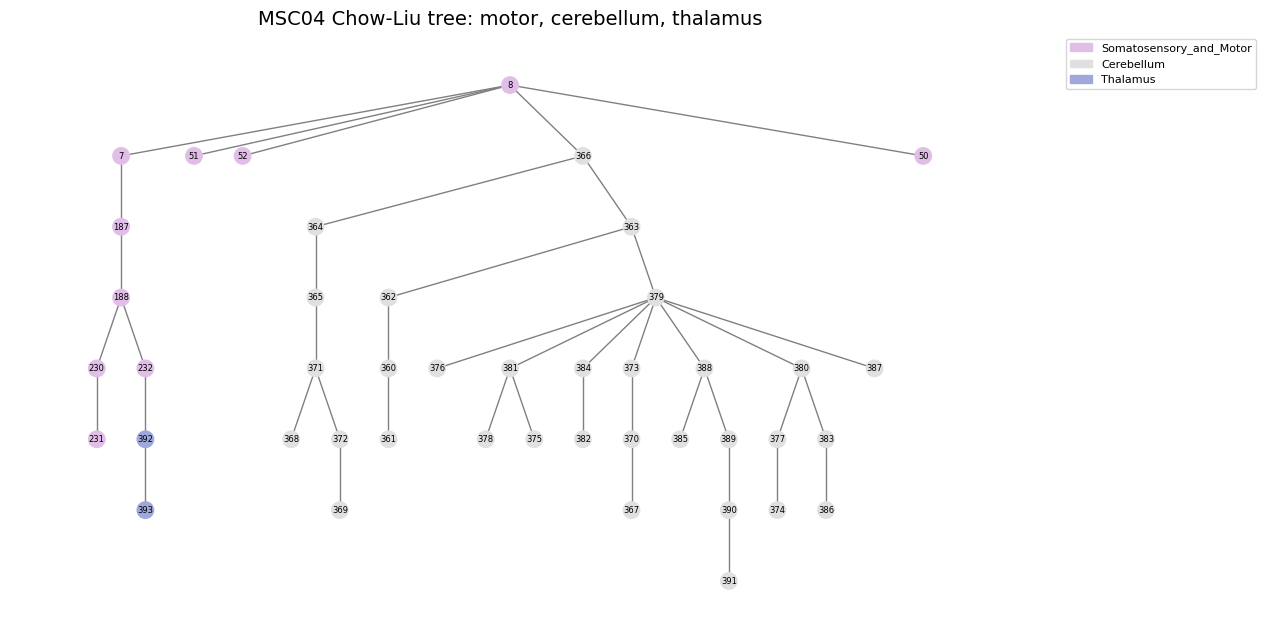

In [74]:
subject = 'MSC04'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 8
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees[subject], atlas_name = 'glasser360_SUIT_Thalamus', root=root, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], title=f"{subject} Chow-Liu tree: motor, cerebellum, thalamus")

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thal

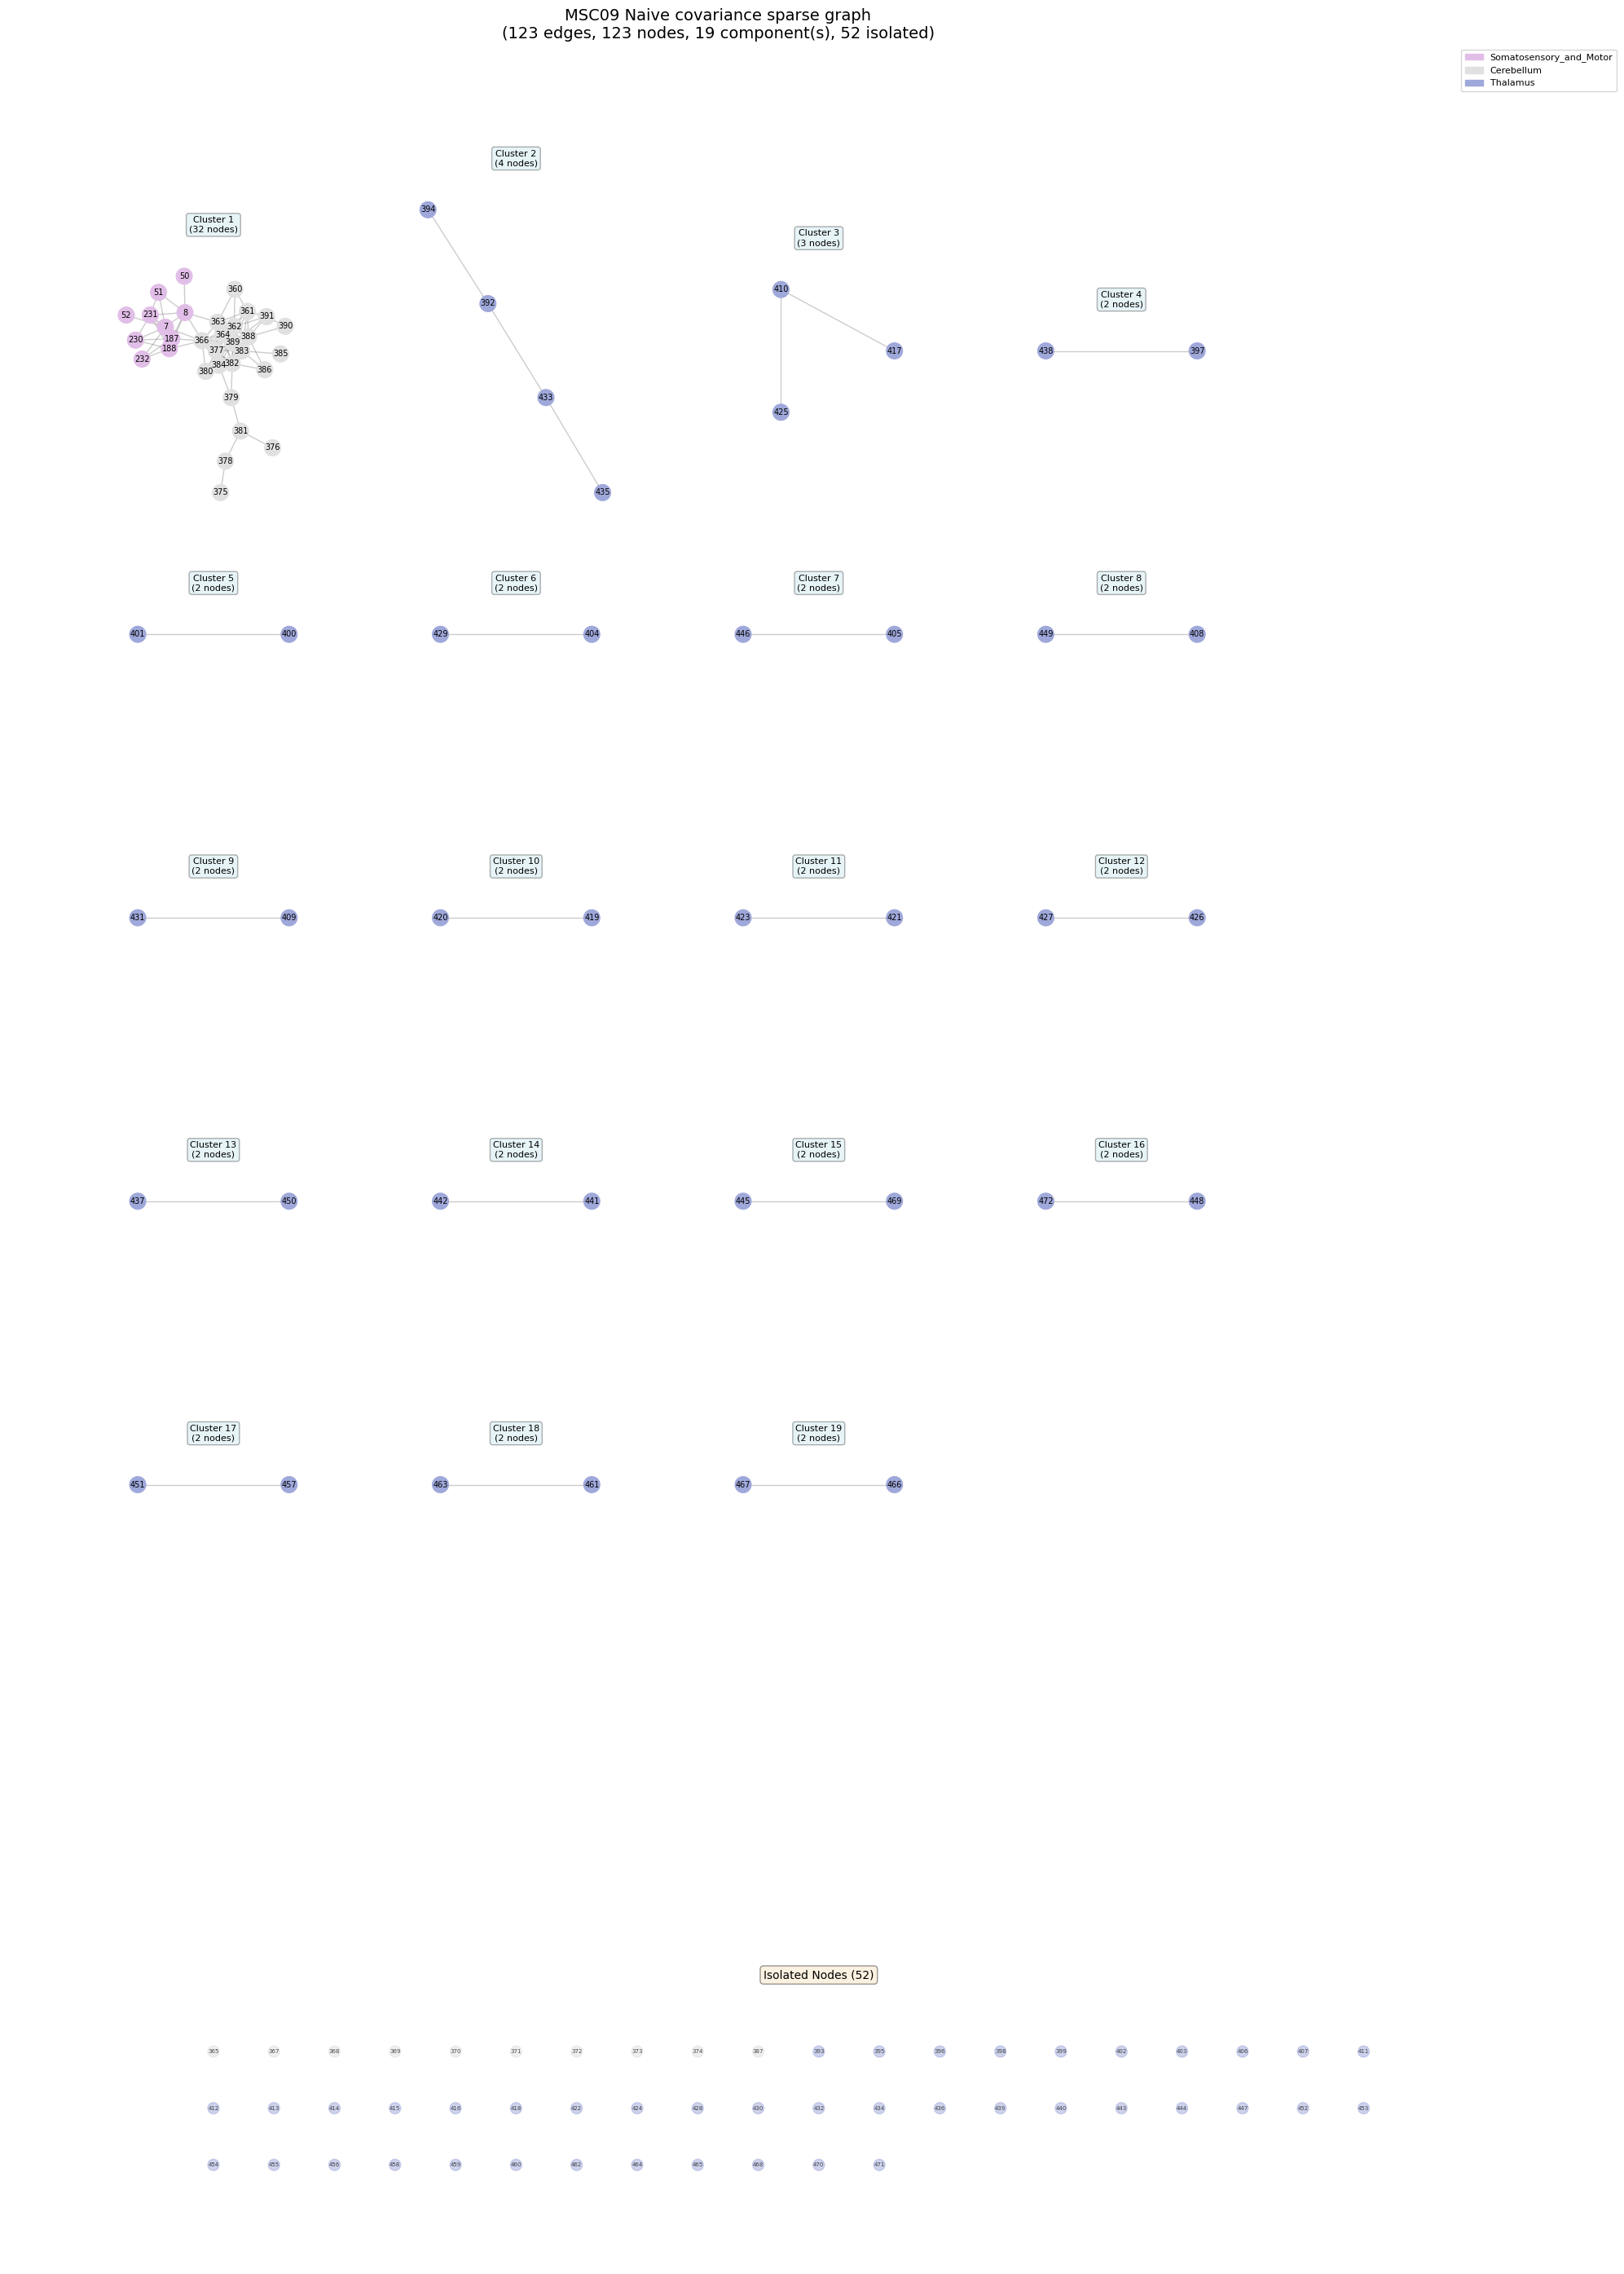

Graph has 123 edges out of 7503 possible edges
Graph density: 0.0164


In [32]:
subject = 'MSC09'
cov_graph, selected_nodes = sparse_covariance_top_edges(cov[100][subject].numpy(), selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])
tree, network_names, colors = draw_covariance_graph(cov_graph, atlas_name = 'glasser360_SUIT_Thalamus', selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], root=8, title=f'{subject} Naive covariance sparse graph', layout='kamada')

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum']


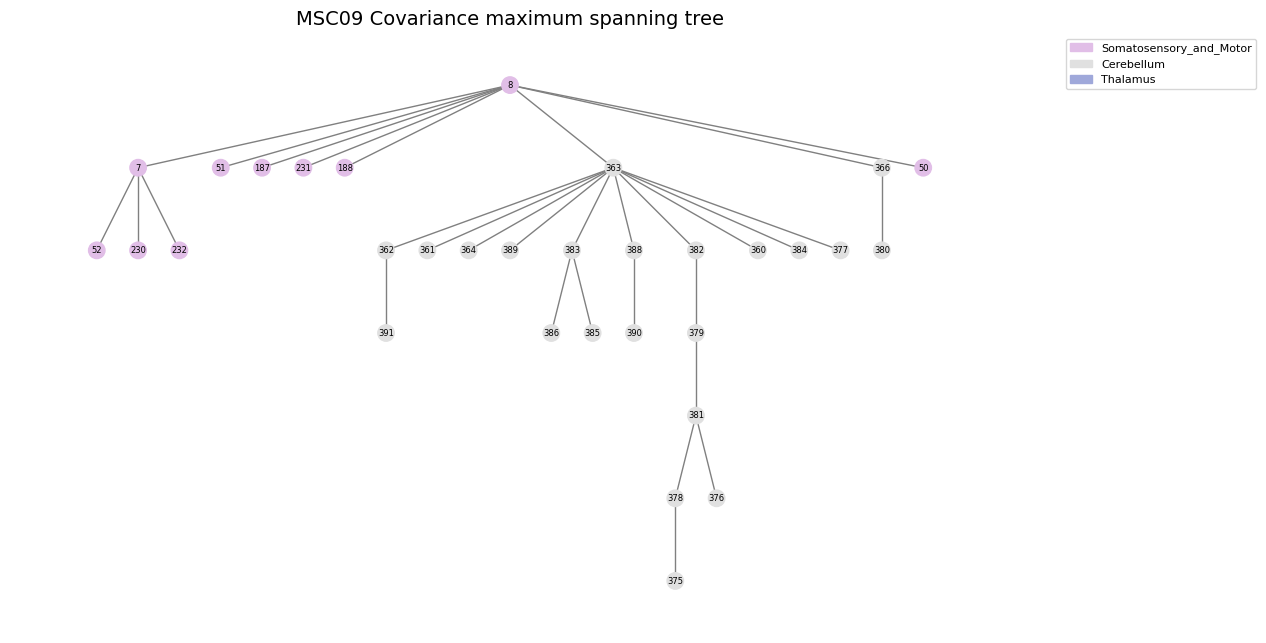

In [33]:
tree, network_names, colors, _ = draw_hierarchical_tree(cov_graph, atlas_name = 'glasser360_SUIT_Thalamus', selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], root=8, title=f'{subject} Covariance maximum spanning tree')

['Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Cerebellum', 'Thalamus', 'Cerebellum', 'Thalamus', 'Thalamus', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Cerebellum', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thalamus', 'Thal

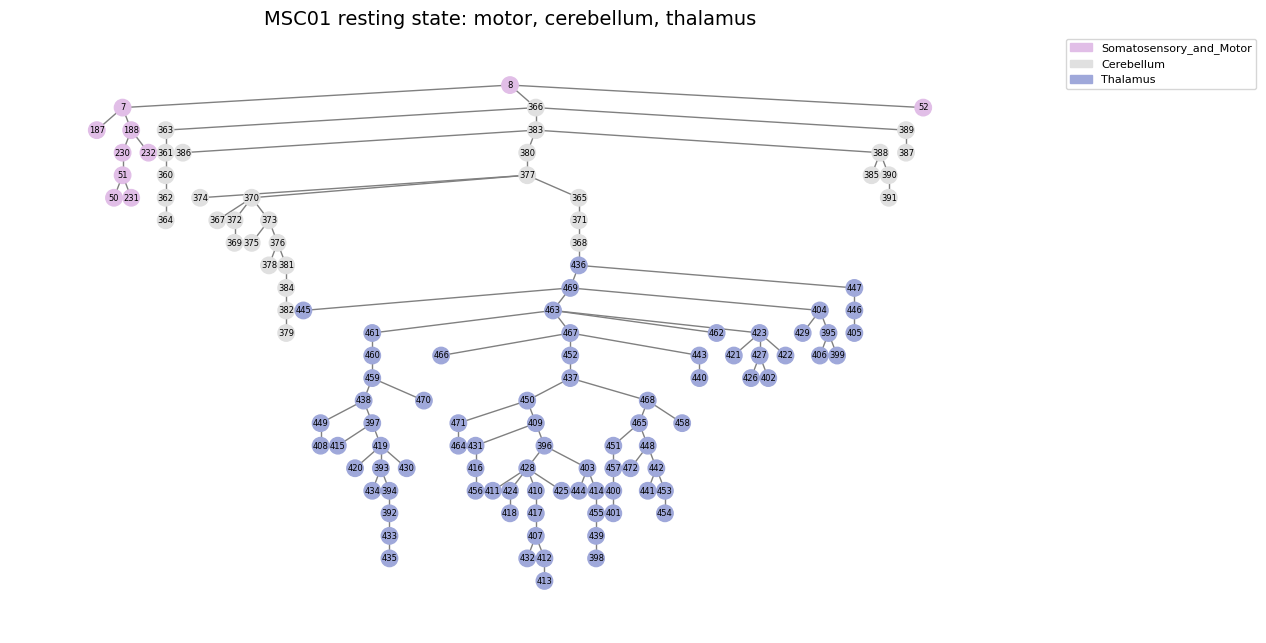

In [34]:
subject = 'MSC01'
# root = list(selective_cl_trees[subject].nodes)[0]
root = 8
tree, pos, network_names, colors = draw_hierarchical_tree(selective_cl_trees[subject], atlas_name = 'glasser360_SUIT_Thalamus', root=root, selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'], title=f"{subject} resting state: motor, cerebellum, thalamus")

In [40]:
len(selective_cl_trees['MSC01'])

123

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection

# Example: generate a random symmetric covariance matrix
n_rois = 394
cov_matrix = cov[100]['MSC01'].numpy()

# Optional: ROI labels
roi_labels = [i]

# Compute circular positions for each ROI
angles = np.linspace(0, 2 * np.pi, n_rois, endpoint=False)
x = np.cos(angles)
y = np.sin(angles)

# Normalize covariance values for color mapping
vmin, vmax = np.min(cov_matrix), np.max(cov_matrix)
norm = plt.Normalize(vmin, vmax)
cmap = cm.coolwarm

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.axis('off')

# Draw circular nodes
for i in range(n_rois):
    ax.plot(x[i], y[i], 'o', color='black', markersize=6)
    ax.text(1.1 * x[i], 1.1 * y[i], roi_labels[i],
            ha='center', va='center', fontsize=9)

# Draw connections (edges) for upper triangle
segments = []
colors = []
for i in range(n_rois):
    for j in range(i+1, n_rois):
        val = cov_matrix[i, j]
        if abs(val) > 0.3:  # optional threshold for clarity
            xi, yi, xj, yj = x[i], y[i], x[j], y[j]
            segments.append([[xi, yi], [xj, yj]])
            colors.append(cmap(norm(val)))

lc = LineCollection(segments, colors=colors, linewidths=2, alpha=0.8)
ax.add_collection(lc)

# Add colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, label='Covariance')

plt.title('Ring Representation of Functional Connectivity', fontsize=13)
plt.show()


NameError: name 'cov' is not defined

## **plotting circuits**

In [ ]:
from nilearn.plotting import plot_roi, show

## **Consistency score**

In [41]:
cov_graphs = {}

for subject in subjects:
    cov_graphs[subject], selected_nodes = sparse_covariance_top_edges(cov[100][subject].numpy(), selected_networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus'])

['Primary_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Dorsal_Stream_Visual', 'Early_Visual', 'Early_Visual', 'Early_Visual', 'Ventral_Stream_Visual', 'Somatosensory_and_Motor', 'Somatosensory_and_Motor', 'Premotor', 'Premotor', 'Premotor', 'Dorsal_Stream_Visual', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Dorsal_Stream_Visual', 'Dorsal_Stream_Visual', 'Ventral_Stream_Visual', 'Dorsal_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Ventral_Stream_Visual', 'MT+_Complex_and_Neighboring_Visual_Areas', 'Early_Auditory', 'Temporo-Parieto_Occipital_Junction', 'Dorsolateral_Prefrontal', 'Posterior_Cingulate', 'Temporo-Parieto-Occipital_Junction', 'Superior_Parietal', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Posterior_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 'Paracentral_Lobular_and_Mid_Cingulate', 

In [43]:
len(cov_graphs['MSC01'])

123

In [51]:
from scipy.linalg import eigh

def spectral_distance(G1, G2, k=10):
    """
    Compare graphs using Laplacian eigenvalues.
    Very fast for large graphs.
    """
    # Get Laplacian matrices
    L1 = nx.laplacian_matrix(G1).toarray()
    L2 = nx.laplacian_matrix(G2).toarray()
    
    # Get k smallest eigenvalues
    evals1 = np.sort(eigh(L1, eigvals_only=True)[:k])
    evals2 = np.sort(eigh(L2, eigvals_only=True)[:k])
    
    # Euclidean distance between eigenvalue vectors
    return np.linalg.norm(evals1 - evals2)

In [58]:
cl_graph_dists = {}
cl_graph_dists['spectral dist'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = selective_cl_trees[subjects[i]]
        G2 = selective_cl_trees[subjects[j]]
        cl_graph_dists['spectral dist'][i, j] = spectral_distance(G1, G2)

comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09


In [61]:
cov_graph_dists = {}
cov_graph_dists['spectral dist'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = cov_graphs[subjects[i]]
        G2 = cov_graphs[subjects[j]]
        cov_graph_dists['spectral dist'][i, j] = spectral_distance(G1, G2)

comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09


In [62]:
cov_graph_dists['spectral dist']

array([[0.00000000e+00, 2.51859683e-06, 2.08813435e-06, 3.30559146e-06],
       [0.00000000e+00, 0.00000000e+00, 1.40346128e-06, 9.30624878e-07],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.67087217e-06],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [63]:
cl_graph_dists['spectral dist']

array([[0.        , 0.00993351, 0.02440318, 0.02493644],
       [0.        , 0.        , 0.01715287, 0.02231056],
       [0.        , 0.        , 0.        , 0.01540633],
       [0.        , 0.        , 0.        , 0.        ]])

In [64]:
def deltacon(G1, G2, exact=False):
    """
    Fast similarity measure based on node affinities.
    One of the best for large graphs.
    """
    # Get adjacency matrices (need same node set)
    nodes = sorted(set(G1.nodes()) | set(G2.nodes()))
    A1 = nx.to_numpy_array(G1, nodelist=nodes)
    A2 = nx.to_numpy_array(G2, nodelist=nodes)
    
    n = len(nodes)
    
    # Fast belief propagation affinity
    # S = (I + eps*D)^-1 * (I + eps*A)
    eps = 1.0 / (1.0 + np.max([A1.sum(), A2.sum()]))
    
    I = np.eye(n)
    D1 = np.diag(A1.sum(axis=1))
    D2 = np.diag(A2.sum(axis=1))
    
    S1 = np.linalg.inv(I + eps * D1) @ (I + eps * A1)
    S2 = np.linalg.inv(I + eps * D2) @ (I + eps * A2)
    
    # Root Euclidean Distance
    distance = np.sqrt(np.sum((np.sqrt(S1) - np.sqrt(S2)) ** 2))
    
    # Normalize to [0, 1]
    similarity = 1.0 / (1.0 + distance)
    
    return 1 - similarity  # Return distance

In [ ]:
cl_graph_dists = {}
cl_graph_dists['deltacon'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = selective_cl_trees[subjects[i]]
        G2 = selective_cl_trees[subjects[j]]
        cl_graph_dists['deltacon'][i, j] = deltacon(G1, G2)


cov_graph_dists = {}
cov_graph_dists['deltacon'] = np.zeros((len(subjects), len(subjects)))

for i in range(len(subjects)):
    for j in range(i+1, len(subjects)):
        if i==j:
            continue
        print(f'comparing {subjects[i]} and {subjects[j]}')
        G1 = cov_graphs[subjects[i]]
        G2 = cov_graphs[subjects[j]]
        cov_graph_dists['deltacon'][i, j] = deltacon(G1, G2)

comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09
comparing MSC01 and MSC04
comparing MSC01 and MSC07
comparing MSC01 and MSC09
comparing MSC04 and MSC07
comparing MSC04 and MSC09
comparing MSC07 and MSC09


In [68]:
print(cl_graph_dists['deltacon'])
print(cov_graph_dists['deltacon'])

[[0.         0.45096027 0.47333767 0.46722283]
 [0.         0.         0.46088948 0.43884166]
 [0.         0.         0.         0.43982375]
 [0.         0.         0.         0.        ]]
[[0.         0.53354849 0.54067893 0.49693246]
 [0.         0.         0.48943917 0.50740005]
 [0.         0.         0.         0.50631385]
 [0.         0.         0.         0.        ]]


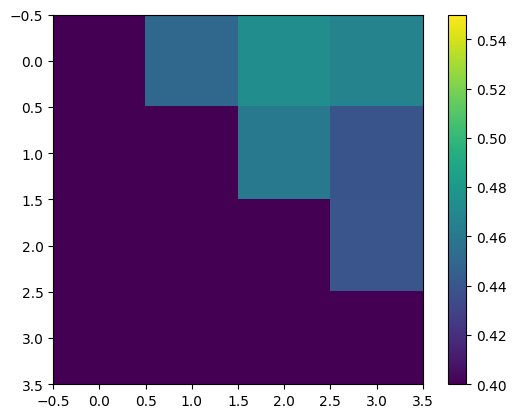

In [72]:
plt.imshow(cl_graph_dists['deltacon'], vmin=0.4, vmax=0.55)
plt.colorbar()

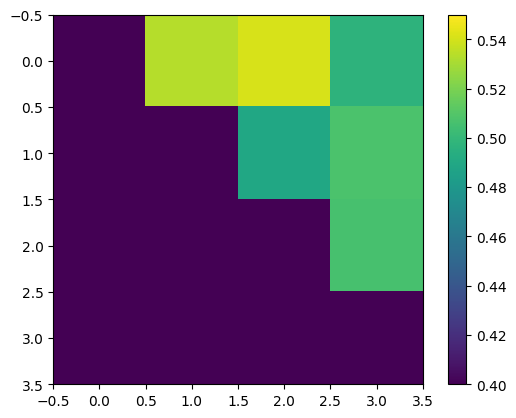

In [79]:
plt.imshow(cov_graph_dists['deltacon'], vmin=0.4, vmax=0.55)
plt.colorbar()

In [73]:
nonzero_cl_graph_dists = cl_graph_dists['deltacon'][cl_graph_dists['deltacon'] > 0]
nonzero_cov_graph_dists = cov_graph_dists['deltacon'][cov_graph_dists['deltacon'] > 0]

<BarContainer object of 2 artists>

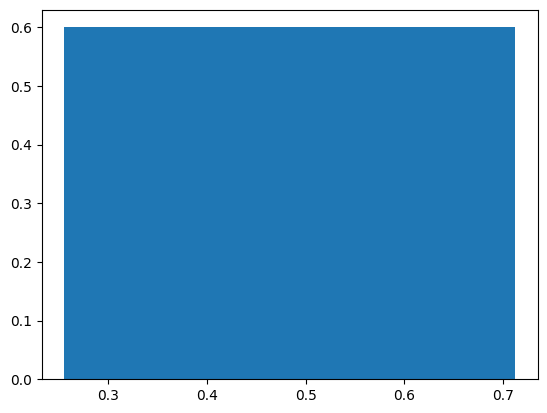

In [78]:
plt.bar((np.mean(nonzero_cl_graph_dists), np.mean(nonzero_cov_graph_dists)), width=0.4, height=0.6, label=['Chow-Liu', 'Covariance'])

<BarContainer object of 6 artists>

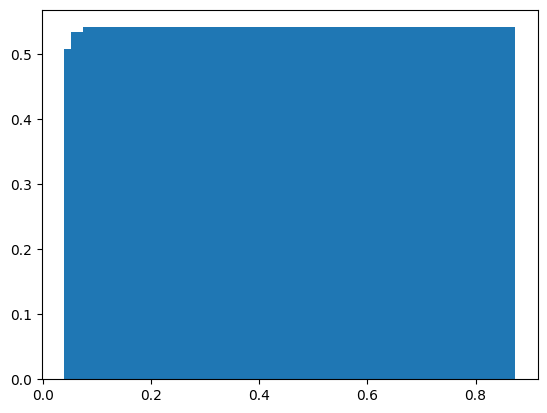

In [74]:
# Pairwise comparisons
print("\nPairwise comparisons (Mann-Whitney U):")
for i in range(len(set_names)):
    for j in range(i + 1, len(set_names)):
        u_stat, p_val = stats.mannwhitneyu(
            all_distances[set_names[i]], 
            all_distances[set_names[j]]
        )
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        print(f"  {set_names[i]} vs {set_names[j]}: p = {p_val:.4e} {sig}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors_multi = ['#E1BEE7', '#BA68C8', '#9C27B0', '#7B1FA2', '#4A148C'][:len(set_names)]

bars = ax.bar(set_names, all_means, yerr=all_sems, capsize=10,
                color=colors_multi, alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Mean Distance', fontsize=12, fontweight='bold')
ax.set_title(title, fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')

# Add sample sizes
for i, (name, distances) in enumerate(all_distances.items()):
    ax.text(i, -max(all_means)*0.05, f'n={len(distances)}', 
            ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

return all_distances